# Preparation+datasets

## Library 

In [2]:
pip install pandas numpy torch scikit-learn scipy tqdm ipykernel yfinance matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## SET-UP+Dataset

In [3]:
"""
High-Frequency Data Preprocessing Module.
Loads realized variance datasets, selects relevant features, 
and applies scaling for numerical stability in downstream models.
"""

import logging
import pandas as pd
import yfinance as yf

# Configure logging for standard output
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def load_and_preprocess_rv_data(file_path: str, scale_factor: float = 10000.0) -> pd.DataFrame:
    """
    Loads and preprocesses high-frequency realized volatility data.
    Args:
        file_path (str): Path to the dataset (CSV format).
        scale_factor (float): Multiplier to prevent numerical underflow 
                              and stabilize gradients in deep learning architectures.
                              Default is 10000.0 (e.g., transforms 0.000347 to 3.47).
    Returns:
        pd.DataFrame: Processed and scaled dataframe.
    """
    try:
        logger.info(f"Loading data from {file_path}")
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        logger.error(f"File not found: {file_path}")
        raise

    target_columns = [
        'date',      # Trading date identifier
        'symbol',    # Asset ticker
        'rv5_ss',    # Subsampled Realized Variance (5m)
        'bv5_ss',    # Subsampled Bipower Variation (5m)
        'rsp5_ss',   # Subsampled Positive Realized Semivariance (5m)
        'rsn5_ss'    # Subsampled Negative Realized Semivariance (5m)
    ]

    # Verify all required columns are present to avoid silent failures
    missing_cols = [col for col in target_columns if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns in dataset: {missing_cols}")

    # Subset and decouple from the original DataFrame to avoid SettingWithCopyWarning
    df_filtered = df[target_columns].copy()

    # Parse dates to ensure proper time-series indexing and handling
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])

    # Apply scaling strictly to variance columns
    variance_cols = ['rv5_ss', 'bv5_ss', 'rsp5_ss', 'rsn5_ss']
    df_filtered[variance_cols] = df_filtered[variance_cols] * scale_factor

    logger.info("Data preprocessing and scaling completed successfully.")
    
    return df_filtered

def get_daily_returns(tickers, start="2015-01-01", end="2025-12-31"):
    """Downloads daily close prices and computes scaled log-returns."""
    logger.info(f"Downloading daily data for {len(tickers)} tickers...")
    data = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=False)

    close = data["Close"] if isinstance(data.columns, pd.MultiIndex) else data[["Close"]].rename(columns={"Close": tickers[0]})
    
    log_returns = (np.log(close) * 100).diff().dropna()
    return log_returns.replace([np.inf, -np.inf], np.nan).dropna(how="all")

def compute_metrics(y_true, y_pred, y_prev_ref, eps=1e-10):
    """Computes MSE, MAE, QLIKE, TIC, and Directional Accuracy."""
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), eps)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    ratio = y_true / y_pred
    qlike = np.mean(ratio - np.log(ratio) - 1.0)

    rmse = np.sqrt(mse)
    denom = np.sqrt(np.mean(y_true ** 2)) + np.sqrt(np.mean(y_pred ** 2))
    tic = rmse / denom if denom > 0 else np.nan

    y_prev_ref = max(float(y_prev_ref), eps)
    y_true_ext = np.concatenate(([y_prev_ref], y_true))
    y_pred_ext = np.concatenate(([y_prev_ref], y_pred))

    da = np.mean(np.sign(np.diff(y_true_ext)) == np.sign(np.diff(y_pred_ext)))

    return mse, mae, qlike, tic, da

if __name__ == "__main__":
    # Configuration
    DATA_PATH = 'realized_variance_stocks.csv'
    
    try:
        # Execution
        df_filtered = load_and_preprocess_rv_data(DATA_PATH)
        TICKERS = ["AAPL", "ADBE", "AMD", "AMGN", "AMZN", "AXP", "BA", "CAT", "CRM", "CSCO",
               "CVX", "DIS", "GE", "GOOGL", "GS", "HD", "HON", "IBM", "JNJ", "JPM",
               "KO", "MCD", "META", "MMM", "MRK", "MSFT", "NFLX", "NKE", "NVDA", "ORCL",
               "PG", "PM", "SHW", "TRV", "TSLA", "UNH", "V", "VZ", "WMT", "XOM"]

        # Assumptions: df_filtered and final_results (HAR baselines) are pre-loaded in environment.
    
        log_returns = get_daily_returns(TICKERS, start="2014-12-31", end="2026-04-01")
        # Output verification
        print("\n--- Processed Data (Head) ---")
        print(log_returns.head())
        
    except Exception as e:
        logger.error(f"Pipeline execution failed: {e}")

INFO: Loading data from realized_variance_stocks.csv
INFO: Data preprocessing and scaling completed successfully.
INFO: Downloading daily data for 40 tickers...



--- Processed Data (Head) ---
Ticker          AAPL      ADBE       AMD      AMGN      AMZN       AXP  \
Date                                                                     
2015-01-02 -0.955808 -0.496417  0.000000  0.375968 -0.591404 -0.021503   
2015-01-05 -2.857604 -0.498883 -0.375235 -1.195430 -2.073069 -2.680190   
2015-01-06  0.009413 -2.035022 -1.134227 -3.274770 -2.309805 -2.154222   
2015-01-07  1.392479  0.818985 -1.919452  3.432883  1.054396  1.866712   
2015-01-08  3.770251  2.513494  1.156081 -0.360867  0.681276  1.407543   

Ticker            BA       CAT       CRM      CSCO  ...        PG        PM  \
Date                                                ...                       
2015-01-02 -0.023082  0.381657 -0.118093 -0.757713  ... -0.716131 -0.529330   
2015-01-05 -0.694979 -5.423048 -1.822729 -2.012145  ... -0.476588 -0.755740   
2015-01-06 -1.184833 -0.645533 -1.681581 -0.036963  ... -0.456550  0.854435   
2015-01-07  1.540643  1.537781 -0.473146  0.919970  ...

# Linear Econometrics

In [7]:
"""
Econometric Baseline Models for Realized Volatility Forecasting.
Implements HAR, HAR-CJ, and SHAR models using a pooled panel approach 
with rolling window optimization and a custom QLIKE loss function.
"""

import logging
import warnings
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def prepare_all_features(df):
    """
    Constructs features for HAR, HAR-CJ, and SHAR models.
    Utilizes vectorized pandas operations for maximum performance.
    """
    df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
    df['j'] = np.maximum(df['rv5_ss'] - df['bv5_ss'], 0)
    
    gb = df.groupby('symbol')
    
    def _roll(x, shift_val, window_val):
        return x.shift(shift_val).rolling(window=window_val).mean()

    # Vectorized HAR features
    df['RV_D'] = gb['rv5_ss'].shift(1)
    df['RV_W'] = gb['rv5_ss'].transform(lambda x: _roll(x, 2, 4))
    df['RV_M'] = gb['rv5_ss'].transform(lambda x: _roll(x, 6, 17))

    # Vectorized HAR-CJ features
    df['C_D'] = gb['bv5_ss'].shift(1)
    df['C_W'] = gb['bv5_ss'].transform(lambda x: _roll(x, 2, 4))
    df['C_M'] = gb['bv5_ss'].transform(lambda x: _roll(x, 6, 17))

    df['J_D'] = gb['j'].shift(1)
    df['J_W'] = gb['j'].transform(lambda x: _roll(x, 2, 4))
    df['J_M'] = gb['j'].transform(lambda x: _roll(x, 6, 17))

    # Vectorized SHAR features
    df['RS_plus_D'] = gb['rsp5_ss'].shift(1)
    df['RS_minus_D'] = gb['rsn5_ss'].shift(1)

    df.rename(columns={'rv5_ss': 'Target'}, inplace=True)
    
    cols_to_keep = [ 'date', 'symbol', 'Target', 'RV_D', 'RV_W', 'RV_M',
        'C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M', 'RS_plus_D', 'RS_minus_D' ]
    
    return df[cols_to_keep].dropna().reset_index(drop=True)

def pooled_ql_loss(params, X, y, ticker_indices, n_assets):
    """
    QLIKE Loss Function for Pooled Panel Data.
    """
    alphas = params[:n_assets]
    betas = params[n_assets:]
    
    y_hat = alphas[ticker_indices] + np.dot(X, betas)
    y_hat = np.maximum(y_hat, 1e-10) 
    
    return np.mean((y / y_hat) - np.log(y / y_hat) - 1.0)

def run_pooled_rolling_optimization(features_df, train_size=1000, test_size=22):
    """
    Executes rolling window optimization using index-based time slicing for efficiency.
    Strictly forces full test_size periods. Partial tail blocks are discarded.
    """
    features_df = features_df.set_index('date').sort_index()
    unique_dates = features_df.index.unique()
    results = []

    # Hard-stop at len() - train_size - test_size to guarantee 82 complete blocks
    max_start_idx = len(unique_dates) - train_size - test_size + 1

    for start_idx in tqdm(range(0, max_start_idx, test_size), desc="Pooled Rolling"):
        end_train_idx = start_idx + train_size - 1
        end_test_idx = start_idx + train_size + test_size - 1

        train_df = features_df.loc[unique_dates[start_idx]:unique_dates[end_train_idx]]
        test_df = features_df.loc[unique_dates[end_train_idx + 1]:unique_dates[end_test_idx]]

        tickers_in_train = train_df['symbol'].unique()
        n_assets = len(tickers_in_train)
        ticker_to_idx = {ticker: i for i, ticker in enumerate(tickers_in_train)}

        test_df = test_df[test_df['symbol'].isin(tickers_in_train)]

        train_indices = train_df['symbol'].map(ticker_to_idx).values
        test_indices = test_df['symbol'].map(ticker_to_idx).values

        y_train = train_df['Target'].values
        
        har_cols = ['RV_D', 'RV_W', 'RV_M']
        cj_cols = ['C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M']
        shar_cols = ['RS_plus_D', 'RS_minus_D', 'RV_W', 'RV_M']

        # Setup optimization components
        alpha_init = [max(np.mean(y_train) * 0.1, 1e-5)] * n_assets 
        alpha_bounds = [(1e-8, None)] * n_assets
        
        configs = { 'HAR': (har_cols, [0.3] * 3),
            'HAR_CJ': (cj_cols, [0.15] * 6),
            'SHAR': (shar_cols, [0.2] * 4) }
        
        preds = {}
        
        for model_name, (cols, beta_init) in configs.items():
            init_params = alpha_init + beta_init
            bounds = alpha_bounds + [(0, None)] * len(beta_init)
            
            res = minimize(
                pooled_ql_loss, 
                init_params, 
                args=(train_df[cols].values, y_train, train_indices, n_assets), 
                method='L-BFGS-B', 
                bounds=bounds
            )
            
            if res.success:
                preds[model_name] = res.x[:n_assets][test_indices] + np.dot(test_df[cols].values, res.x[n_assets:])
                test_df[f'pred_{model_name}'] = np.maximum(preds[model_name], 1e-10)
            else:
                test_df[f'pred_{model_name}'] = np.nan

        # Decompose pooled predictions
        for ticker in tickers_in_train:
            t_test = test_df[test_df['symbol'] == ticker]
            if t_test.empty or t_test['pred_HAR'].isnull().any():
                continue
                
            y_last_train = train_df[train_df['symbol'] == ticker]['Target'].values[-1]
            y_true = t_test['Target'].values
            
            row_res = {'date_test_start': t_test.index[0], 'symbol': ticker}
            
            for mod in configs.keys():
                metrics = compute_metrics(y_true, t_test[f'pred_{mod}'].values, y_last_train)
                row_res.update({
                    f'MSE_{mod}': metrics[0], f'MAE_{mod}': metrics[1], 
                    f'QLIKE_{mod}': metrics[2], f'TIC_{mod}': metrics[3], f'DA_{mod}': metrics[4]
                })
                
            results.append(row_res)

    return pd.DataFrame(results)

def evaluate_performance(results_df):
    """
    Computes ratio metrics against the standard HAR baseline.
    """
    metrics = ['MSE', 'MAE', 'QLIKE', 'TIC', 'DA']
    models = ['HAR_CJ', 'SHAR']

    for m in metrics:
        for model in models:
            results_df[f'Ratio_{model}_{m}'] = results_df[f'{m}_{model}'] / results_df[f'{m}_HAR']

    ratio_cols = [c for c in results_df.columns if c.startswith('Ratio_')]
    
    print("--- GLOBAL RATIO AVERAGES (Baseline: HAR) ---")
    print(results_df[ratio_cols].mean().to_string())
    
    print("\n--- RATIO AVERAGES PER TICKER (Head) ---")
    print(results_df.groupby('symbol')[ratio_cols].mean().head())

if __name__ == "__main__":
    # ASSUMPTION: df_filtered is defined and scaled in the global scope
    features_global = prepare_all_features(df_filtered)
    final_results = run_pooled_rolling_optimization(features_global, train_size=1000, test_size=22)
    evaluate_performance(final_results)

Pooled Rolling:   1%|          | 1/82 [00:04<05:26,  4.04s/it]


KeyboardInterrupt: 

## Multivariate Diebold Test Example

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy import stats
from tqdm import tqdm
import warnings
import logging

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def qlike_loss(y_true, y_pred):
    y_pred = np.maximum(y_pred, 1e-10)
    return (y_true / y_pred) - np.log(y_true / y_pred) - 1.0

def prepare_all_features(df):
    df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
    df['j'] = np.maximum(df['rv5_ss'] - df['bv5_ss'], 0)
    
    gb = df.groupby('symbol')
    def _roll(x, shift_val, window_val):
        return x.shift(shift_val).rolling(window=window_val).mean()

    df['RV_D'] = gb['rv5_ss'].shift(1)
    df['RV_W'] = gb['rv5_ss'].transform(lambda x: _roll(x, 2, 4))
    df['RV_M'] = gb['rv5_ss'].transform(lambda x: _roll(x, 6, 17))

    df['C_D'] = gb['bv5_ss'].shift(1)
    df['C_W'] = gb['bv5_ss'].transform(lambda x: _roll(x, 2, 4))
    df['C_M'] = gb['bv5_ss'].transform(lambda x: _roll(x, 6, 17))

    df['J_D'] = gb['j'].shift(1)
    df['J_W'] = gb['j'].transform(lambda x: _roll(x, 2, 4))
    df['J_M'] = gb['j'].transform(lambda x: _roll(x, 6, 17))

    df['RS_plus_D'] = gb['rsp5_ss'].shift(1)
    df['RS_minus_D'] = gb['rsn5_ss'].shift(1)

    df.rename(columns={'rv5_ss': 'Target'}, inplace=True)
    cols_to_keep = ['date', 'symbol', 'Target', 'RV_D', 'RV_W', 'RV_M',
                    'C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M', 'RS_plus_D', 'RS_minus_D']
    return df[cols_to_keep].dropna().reset_index(drop=True)

def pooled_ql_loss(params, X, y, ticker_indices, n_assets):
    alphas = params[:n_assets]
    betas = params[n_assets:]
    y_hat = alphas[ticker_indices] + np.dot(X, betas)
    y_hat = np.maximum(y_hat, 1e-10) 
    return np.mean((y / y_hat) - np.log(y / y_hat) - 1.0)

def run_pooled_rolling_optimization(features_df, train_size=1000, test_size=22):
    features_df = features_df.set_index('date').sort_index()
    unique_dates = features_df.index.unique()
    all_predictions = []

    max_start_idx = len(unique_dates) - train_size - test_size + 1

    for start_idx in tqdm(range(0, max_start_idx, test_size), desc="Pooled Rolling"):
        end_train_idx = start_idx + train_size - 1
        end_test_idx = start_idx + train_size + test_size - 1

        train_df = features_df.loc[unique_dates[start_idx]:unique_dates[end_train_idx]]
        test_df = features_df.loc[unique_dates[end_train_idx + 1]:unique_dates[end_test_idx]].copy()

        tickers_in_train = train_df['symbol'].unique()
        n_assets = len(tickers_in_train)
        ticker_to_idx = {ticker: i for i, ticker in enumerate(tickers_in_train)}

        test_df = test_df[test_df['symbol'].isin(tickers_in_train)]
        train_indices = train_df['symbol'].map(ticker_to_idx).values
        test_indices = test_df['symbol'].map(ticker_to_idx).values
        y_train = train_df['Target'].values
        
        configs = {
            'HAR': (['RV_D', 'RV_W', 'RV_M'], [0.3] * 3),
            'HAR_CJ': (['C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M'], [0.15] * 6),
            'SHAR': (['RS_plus_D', 'RS_minus_D', 'RV_W', 'RV_M'], [0.2] * 4)
        }
        
        alpha_init = [max(np.mean(y_train) * 0.1, 1e-5)] * n_assets 
        alpha_bounds = [(1e-8, None)] * n_assets
        
        for model_name, (cols, beta_init) in configs.items():
            init_params = alpha_init + beta_init
            bounds = alpha_bounds + [(0, None)] * len(beta_init)
            
            res = minimize(
                pooled_ql_loss, 
                init_params, 
                args=(train_df[cols].values, y_train, train_indices, n_assets), 
                method='L-BFGS-B', 
                bounds=bounds
            )
            
            if res.success:
                preds = res.x[:n_assets][test_indices] + np.dot(test_df[cols].values, res.x[n_assets:])
                test_df[f'pred_{model_name}'] = np.maximum(preds, 1e-10)
            else:
                test_df[f'pred_{model_name}'] = np.nan
                
        test_df = test_df.reset_index()
        all_predictions.append(test_df[['date', 'symbol', 'Target', 'pred_HAR', 'pred_HAR_CJ', 'pred_SHAR']])

    return pd.concat(all_predictions, ignore_index=True)

def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1):
    d = qlike_loss(y_true, y_pred1) - qlike_loss(y_true, y_pred2)
    n = len(d)
    mean_d = np.mean(d)
    
    def autocov(x, lag):
        if lag >= len(x): return 0
        mean_x = np.mean(x)
        return np.sum((x[:len(x)-lag] - mean_x) * (x[lag:] - mean_x)) / len(x)

    gamma_0 = autocov(d, 0)
    var_d = gamma_0 + sum(2 * autocov(d, lag) for lag in range(1, h))
        
    if var_d <= 0:
        return 0.0, 1.0
        
    stat = mean_d / np.sqrt(var_d / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(stat)))
    return stat, p_value

def cross_sectional_dm_test(df_preds, model1, model2, h=1):
    df_clean = df_preds.dropna(subset=[f'pred_{model1}', f'pred_{model2}'])
    grouped = df_clean.groupby('date')
    
    cross_d = grouped.apply(lambda x: np.mean(qlike_loss(x['Target'].values, x[f'pred_{model1}'].values) - 
                                              qlike_loss(x['Target'].values, x[f'pred_{model2}'].values)))
    
    d_array = cross_d.values
    n = len(d_array)
    mean_d = np.mean(d_array)
    
    def autocov(x, lag):
        if lag >= len(x): return 0
        mean_x = np.mean(x)
        return np.sum((x[:len(x)-lag] - mean_x) * (x[lag:] - mean_x)) / len(x)
        
    var_d = autocov(d_array, 0) + sum(2 * autocov(d_array, lag) for lag in range(1, h))
    
    if var_d <= 0:
        return 0.0, 1.0
        
    stat = mean_d / np.sqrt(var_d / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(stat)))
    return stat, p_value

def evaluate_all_dm_tests(predictions_df):
    print("--- CROSS-SECTIONAL DIEBOLD-MARIANO TEST ---")
    stat_cj, pval_cj = cross_sectional_dm_test(predictions_df, 'HAR', 'HAR_CJ', h=1)
    print(f"HAR vs HAR-CJ -> Stat: {stat_cj:.4f}, p-value: {pval_cj:.4f}")
    
    stat_shar, pval_shar = cross_sectional_dm_test(predictions_df, 'HAR', 'SHAR', h=1)
    print(f"HAR vs SHAR   -> Stat: {stat_shar:.4f}, p-value: {pval_shar:.4f}")

if __name__ == "__main__":
    features_global = prepare_all_features(df_filtered)
    final_predictions = run_pooled_rolling_optimization(features_global, train_size=1000, test_size=22)
    evaluate_all_dm_tests(final_predictions)
    pass

Pooled Rolling: 100%|██████████| 82/82 [04:52<00:00,  3.56s/it]

--- CROSS-SECTIONAL DIEBOLD-MARIANO TEST ---
HAR vs HAR-CJ -> Stat: 6.6443, p-value: 0.0000
HAR vs SHAR   -> Stat: -0.4871, p-value: 0.6262


# GHAR and GHAR-CJ

## GHAR

In [ ]:
"""
==============================================================================
 GHAR (Graphical Lasso HAR) Forecasting + Graph Diagnostics Module
==============================================================================

This module:
- Estimates rolling GLASSO networks from daily equity returns.
- Uses the normalized adjacency matrix inside a pooled GHAR model.
- Forecasts realized volatility using QLIKE optimization.
- Stores and analyzes the estimated graph at each rolling window.
- Identifies persistent ticker clusters across rolling windows.

Graph diagnostics include:
- Average degree, Density, Centrality (Degree, Betweenness), Clustering
- Community detection via greedy modularity
- Jaccard similarity between consecutive rolling graphs and Edge turnover
- Persistent co-clustering and evolution tracking
"""

import warnings
import logging
import numpy as np
import pandas as pd
import yfinance as yf
import networkx as nx

from scipy.optimize import minimize
from sklearn.covariance import GraphicalLassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from networkx.algorithms.community import greedy_modularity_communities, modularity
from tqdm import tqdm

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# ==============================================================================
# 1. FEATURE PREPARATION
# ==============================================================================

def prepare_ghar_features(df):
    """Prepares non-overlapping HAR features (Daily, Weekly, Monthly)."""
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

    gb = df.groupby("symbol")["rv5_ss"]
    df["RV_D"] = gb.shift(1)
    df["RV_W"] = gb.transform(lambda x: x.shift(2).rolling(window=4).mean())
    df["RV_M"] = gb.transform(lambda x: x.shift(6).rolling(window=17).mean())

    df = df.rename(columns={"rv5_ss": "Target"})
    return df[["date", "symbol", "Target", "RV_D", "RV_W", "RV_M"]].dropna().reset_index(drop=True)

# ==============================================================================
# 2. GLASSO NETWORK ESTIMATION
# ==============================================================================

def EWMA_GLASSO_Precision(returns_matrix, span=44, precision_tol=1e-2, alphas=10, cv=2, max_iter=300): 
    """Estimates a sparse graph from daily returns using EWMA scaling + GLASSO."""
    tickers = list(returns_matrix.columns)
    returns_matrix = returns_matrix.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    ewma_std = returns_matrix.ewm(span=span, min_periods=1).std().bfill().ffill()
    ewma_std = ewma_std.mask(ewma_std < 1e-8, 1.0)

    scaled_returns = returns_matrix.to_numpy(dtype=float) / ewma_std.to_numpy(dtype=float)
    scaled_returns = np.nan_to_num(scaled_returns, nan=0.0, posinf=0.0, neginf=0.0)

    model = GraphicalLassoCV(alphas=alphas, cv=cv, assume_centered=True, max_iter=max_iter, n_jobs=-1)
    model.fit(scaled_returns)

    precision = model.precision_.copy()
    scale = max(float(np.nanmax(np.abs(precision))), 1.0)
    threshold = precision_tol * scale

    adj_bin = (np.abs(precision) > threshold).astype(float)
    np.fill_diagonal(adj_bin, 0.0)
    adj_bin = np.maximum(adj_bin, adj_bin.T)

    degree = adj_bin.sum(axis=1)
    avg_degree = float(degree.mean())

    inv_sqrt_degree = np.zeros_like(degree, dtype=float)
    non_isolated = degree > 0
    inv_sqrt_degree[non_isolated] = 1.0 / np.sqrt(degree[non_isolated])

    adj_norm = inv_sqrt_degree[:, None] * adj_bin * inv_sqrt_degree[None, :]

    return ( pd.DataFrame(adj_norm, index=tickers, columns=tickers),
        avg_degree,
        pd.DataFrame(adj_bin, index=tickers, columns=tickers),
        pd.DataFrame(precision, index=tickers, columns=tickers) )

# ==============================================================================
# 3. GRAPH DIAGNOSTICS
# ==============================================================================

def edge_set_from_adj(adj_bin_df):
    """Extracts the undirected edge set from a binary adjacency matrix."""
    tickers, A = list(adj_bin_df.index), adj_bin_df.to_numpy(dtype=float)
    edges, n = set(), len(tickers)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                edges.add((tickers[i], tickers[j]))
    return edges


def jaccard_similarity_edges(edges_current, edges_previous):
    """Computes the Jaccard similarity between two consecutive edge sets."""
    if edges_previous is None:
        return np.nan
    union = edges_current | edges_previous
    return len(edges_current & edges_previous) / len(union) if union else np.nan

def format_top_nodes(values_dict, k=5, decimals=3):
    """Formats top-k centrality values as a compact string."""
    top = sorted(values_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    return ", ".join([f"{name} ({value:.{decimals}f})" for name, value in top])

def analyze_binary_graph(adj_bin_df, top_k=5):
    """Computes window-level graph diagnostics and node-level metrics."""
    A = np.maximum(adj_bin_df.to_numpy(dtype=float), adj_bin_df.to_numpy(dtype=float).T)
    np.fill_diagonal(A, 0.0)
    G = nx.from_numpy_array(A)
    mapping = dict(enumerate(adj_bin_df.index))
    G = nx.relabel_nodes(G, mapping)

    n_nodes, n_edges = G.number_of_nodes(), G.number_of_edges()
    degrees, degree_centrality = dict(G.degree()), nx.degree_centrality(G)

    if n_edges > 0:
        betweenness = nx.betweenness_centrality(G, normalized=True)
        avg_clustering = nx.average_clustering(G)
        communities = list(greedy_modularity_communities(G))
        graph_modularity = modularity(G, communities)
        community_labels = {node: c_id for c_id, comm in enumerate(communities, 1) for node in comm}
    else:
        betweenness, avg_clustering, communities, graph_modularity = {n: 0.0 for n in G.nodes()}, 0.0, [], np.nan
        community_labels = {n: np.nan for n in G.nodes()}

    graph_summary = {
        "Graph_Num_Nodes": n_nodes,
        "Graph_Num_Edges": n_edges,
        "Graph_Avg_Degree": float(np.mean(list(degrees.values()))) if n_nodes > 0 else np.nan,
        "Graph_Density": nx.density(G) if n_nodes > 1 else np.nan,
        "Graph_Avg_Clustering": avg_clustering,
        "Graph_Num_Communities": len(communities),
        "Graph_Modularity": graph_modularity,
        "Top5_Degree_Centrality": format_top_nodes(degree_centrality, top_k),
        "Top5_Betweenness_Centrality": format_top_nodes(betweenness, top_k),
    }

    node_df = pd.DataFrame([{
        "symbol": node, "degree": degrees[node], "degree_centrality": degree_centrality[node],
        "betweenness_centrality": betweenness[node], "community": community_labels[node]
    } for node in G.nodes()])

    return graph_summary, node_df

def summarize_overall_node_centrality(node_centrality_df, top_k=5):
    """Aggregates overall top stocks by average degree and betweenness centrality."""
    if node_centrality_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    top_degree = node_centrality_df.groupby("symbol", as_index=False).agg(
        avg_degree=("degree", "mean"), avg_degree_centrality=("degree_centrality", "mean")
    ).sort_values("avg_degree_centrality", ascending=False).head(top_k)

    top_betweenness = node_centrality_df.groupby("symbol", as_index=False).agg(
        avg_betweenness_centrality=("betweenness_centrality", "mean")
    ).sort_values("avg_betweenness_centrality", ascending=False).head(top_k)

    return top_degree, top_betweenness

# ==============================================================================
# 4. PERSISTENT CLUSTERING
# ==============================================================================

def compute_persistent_clusters(node_centrality_df, threshold=0.80, min_cluster_size=2):
    """Identifies persistent ticker clusters based on co-clustering frequency."""
    df = node_centrality_df.dropna(subset=["community"]).copy()
    df["date_test_start"] = pd.to_datetime(df["date_test_start"])
    symbols = sorted(df["symbol"].unique())
    symbol_to_idx = {s: i for i, s in enumerate(symbols)}
    n = len(symbols)

    same_count, total_count = np.zeros((n, n)), np.zeros((n, n))

    for _, sub in df.groupby("date_test_start"):
        present = sub["symbol"].tolist()
        communities = dict(zip(sub["symbol"], sub["community"]))
        for s1 in present:
            idx1 = symbol_to_idx[s1]
            for s2 in present:
                idx2 = symbol_to_idx[s2]
                total_count[idx1, idx2] += 1
                if communities[s1] == communities[s2]:
                    same_count[idx1, idx2] += 1

    coclustering = same_count / np.maximum(total_count, 1)
    coclustering_df = pd.DataFrame(coclustering, index=symbols, columns=symbols)

    G = nx.Graph()
    G.add_nodes_from(symbols)
    for i in range(n):
        for j in range(i + 1, n):
            if coclustering[i, j] >= threshold:
                G.add_edge(symbols[i], symbols[j], weight=coclustering[i, j])

    components = sorted([sorted(list(c)) for c in nx.connected_components(G) if len(c) >= min_cluster_size], key=lambda x: (-len(x), x[0]))

    cluster_map = {ticker: f"Cluster_{i}" for i, members in enumerate(components, 1) for ticker in members}
    cluster_rows = [{"persistent_cluster": f"Cluster_{i}", "size": len(members), "members": ", ".join(members)} for i, members in enumerate(components, 1)]

    ticker_assignment_df = pd.DataFrame({"symbol": symbols, "persistent_cluster": [cluster_map.get(s, "None") for s in symbols]})
    return ticker_assignment_df, pd.DataFrame(cluster_rows), coclustering_df

def build_cluster_evolution_table(node_centrality_df, ticker_assignment_df):
    """Tracks stability of persistent clusters within each rolling window."""
    df = node_centrality_df.copy()
    df["date_test_start"] = pd.to_datetime(df["date_test_start"])
    assignment = ticker_assignment_df[ticker_assignment_df["persistent_cluster"] != "None"]

    df = df.merge(assignment, on="symbol", how="inner")
    rows = []

    for (date, p_cluster), sub in df.groupby(["date_test_start", "persistent_cluster"]):
        counts = sub["community"].value_counts()
        rows.append({ "date_test_start": date,
            "persistent_cluster": p_cluster,
            "dominant_rolling_community": int(counts.index[0]),
            "members_observed": len(sub),
            "share_together_in_window": counts.iloc[0] / len(sub),
            "members": ", ".join(sorted(sub["symbol"])) })

    return pd.DataFrame(rows).sort_values(["date_test_start", "persistent_cluster"]).reset_index(drop=True)

# ==============================================================================
# 5. GHAR LOSS FUNCTION
# ==============================================================================

def pooled_ql_loss(params, X, y, asset_indices, n_assets, lambda_ridge=1e-1):
    """Pooled QLIKE loss with asset-specific intercepts and shared coefficients."""
    alphas, betas = params[:n_assets], params[n_assets:]
    y_hat = np.maximum(alphas[asset_indices] + X @ betas, 1e-10)
    
    ratio = y / y_hat
    qlike = np.mean(ratio - np.log(ratio) - 1.0)
    penalty = lambda_ridge * np.sum(betas[3:] ** 2)

    return qlike + penalty

# ==============================================================================
# 6. MAIN ROLLING PIPELINE
# ==============================================================================

def run_pooled_ewma_ghar(df_filtered, log_returns, window=22, train_size=1000, ewma_span=44, precision_tol=1e-2, lambda_ridge=1e-1):
    """Executes the rolling GHAR framework and extracts network topologies."""
    features_df = prepare_ghar_features(df_filtered).set_index("date").sort_index()
    rv_pivot = df_filtered.pivot(index="date", columns="symbol", values="rv5_ss").sort_index().ffill().bfill()
    returns_pivot = log_returns.reindex(index=rv_pivot.index, columns=rv_pivot.columns).fillna(0.0)

    unique_dates = features_df.index.unique()
    all_metrics, graph_diag_rows, node_cent_rows = [], [], []
    adj_bin_dict, adj_norm_dict, prec_dict = {}, {}, {}
    previous_edges = None

    for start_idx in tqdm(range(train_size, len(unique_dates) - window, window), desc="GHAR Rolling"):
        train_dates, test_dates = unique_dates[start_idx - train_size : start_idx], unique_dates[start_idx : start_idx + window]
        date_test_start, date_test_end = test_dates[0], test_dates[-1]

        train_df, test_df = features_df.loc[train_dates[0]:train_dates[-1]].copy(), features_df.loc[test_dates[0]:test_dates[-1]].copy()
        
        adj_norm, avg_degree, adj_bin, precision_df = EWMA_GLASSO_Precision(returns_pivot.loc[train_dates], span=ewma_span, precision_tol=precision_tol)

        adj_bin_dict[date_test_start], adj_norm_dict[date_test_start], prec_dict[date_test_start] = adj_bin.copy(), adj_norm.copy(), precision_df.copy()

        graph_summary, node_df = analyze_binary_graph(adj_bin)
        current_edges = edge_set_from_adj(adj_bin)
        jaccard = jaccard_similarity_edges(current_edges, previous_edges)
        previous_edges = current_edges

        graph_summary.update({ "date_test_start": date_test_start, "date_test_end": date_test_end,
            "Graph_Jaccard_Prev": jaccard, "Graph_Edge_Turnover": 1.0 - jaccard if pd.notna(jaccard) else np.nan,
            "Train_Avg_RV": float(rv_pivot.loc[train_dates].mean().mean()), "Test_Avg_RV": float(rv_pivot.loc[test_dates].mean().mean()), })
        graph_diag_rows.append(graph_summary)
        
        node_df["date_test_start"], node_df["date_test_end"] = date_test_start, date_test_end
        node_cent_rows.append(node_df)

        net_d = rv_pivot.shift(1).dot(adj_norm).stack()
        net_w = rv_pivot.shift(2).rolling(4).mean().dot(adj_norm).stack()
        net_m = rv_pivot.shift(6).rolling(17).mean().dot(adj_norm).stack()

        def map_features(df_t):
            idx = pd.MultiIndex.from_arrays([df_t.index, df_t["symbol"]])
            df_t["Net_D"], df_t["Net_W"], df_t["Net_M"] = idx.map(net_d), idx.map(net_w), idx.map(net_m)
            return df_t

        train_df, test_df = map_features(train_df).dropna(), map_features(test_df).dropna()
        tickers = sorted(train_df["symbol"].unique())
        test_df = test_df[test_df["symbol"].isin(tickers)]
        if test_df.empty: continue

        feature_cols = ["RV_D", "RV_W", "RV_M", "Net_D", "Net_W", "Net_M"]
        X_train, y_train, X_test = train_df[feature_cols].to_numpy(), train_df["Target"].to_numpy(), test_df[feature_cols].to_numpy()
        
        ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
        train_idx, test_idx = train_df["symbol"].map(ticker_to_idx).to_numpy(), test_df["symbol"].map(ticker_to_idx).to_numpy()

        init_params = np.array([max(np.mean(y_train) * 0.1, 1e-5)] * len(tickers) + [0.3, 0.2, 0.1, 0.1, 0.05, 0.02])
        bounds = [(1e-8, None)] * len(tickers) + [(0.0, None)] * 6

        res = minimize(pooled_ql_loss, init_params, args=(X_train, y_train, train_idx, len(tickers), lambda_ridge), method="L-BFGS-B", bounds=bounds, options={"maxiter": 1000, "ftol": 1e-10})
        test_df["Pred_GHAR"] = np.maximum(res.x[:len(tickers)][test_idx] + X_test @ res.x[len(tickers):], 1e-10) if res.success else np.nan

        for ticker in tickers:
            t_test, t_train = test_df[test_df["symbol"] == ticker], train_df[train_df["symbol"] == ticker]
            if t_test.empty or t_train.empty or t_test["Pred_GHAR"].isnull().any(): continue

            mse, mae, qlike, tic, da = compute_metrics(t_test["Target"].to_numpy(), t_test["Pred_GHAR"].to_numpy(), t_train["Target"].to_numpy()[-1])
            all_metrics.append({"symbol": ticker, "date_test_start": date_test_start, "date_test_end": date_test_end, "Graph_Avg_Degree": avg_degree, "MSE_GHAR": mse, "MAE_GHAR": mae, "QLIKE_GHAR": qlike, "TIC_GHAR": tic, "DA_GHAR": da})

    return (
        pd.DataFrame(all_metrics), pd.DataFrame(graph_diag_rows),
        pd.concat(node_cent_rows, ignore_index=True) if node_cent_rows else pd.DataFrame(),
        adj_bin_dict, adj_norm_dict, prec_dict
    )

# ==============================================================================
# 7. REPORTING
# ==============================================================================

def print_ghar_report(comp_df, graph_diag_df, node_cent_df, ghar_res, adj_bin_dict, p_clusters_df, t_assignment_df, c_evo_df):
    """Outputs integrated forecast comparisons and network topology diagnostics."""
    for m in ["MSE", "MAE", "QLIKE", "TIC", "DA"]:
        comp_df[f"Ratio_GHAR_{m}"] = comp_df[f"{m}_GHAR"] / comp_df[f"{m}_HAR"]

    print("\n" + "=" * 90 + "\nGLOBAL COMPARISON: GHAR vs HAR\n" + "=" * 90)
    print("Ratios < 1 indicate GHAR outperformance, except for DA where > 1 is better.")
    print(comp_df[[f"Ratio_GHAR_{m}" for m in ["MSE", "MAE", "QLIKE", "TIC", "DA"]]].mean().to_string())

    print("\n" + "=" * 90 + "\nGRAPH DIAGNOSTICS: ROLLING AVERAGES\n" + "=" * 90)
    print(graph_diag_df.mean(numeric_only=True).to_string())

    top_d, top_b = summarize_overall_node_centrality(node_cent_df)
    print("\n" + "=" * 90 + "\nOVERALL TOP 5 STOCKS BY DEGREE / BETWEENNESS CENTRALITY\n" + "=" * 90)
    print(top_d.to_string(index=False), "\n\n", top_b.to_string(index=False))

    print("\n" + "=" * 90 + "\nPERSISTENT CLUSTERS (80% CO-CLUSTERING THRESHOLD)\n" + "=" * 90)
    print(p_clusters_df.to_string(index=False))

    print("\n" + "=" * 90 + "\nCLUSTER EVOLUTION ACROSS ROLLING WINDOWS (HEAD)\n" + "=" * 90)
    print(c_evo_df.head(15).to_string(index=False))

# ==============================================================================
# 8. EXECUTION
# ==============================================================================

if __name__ == "__main__":

    ( final_ghar_results, graph_diagnostics_df, node_centrality_df,
        adjacency_binary_matrices, adjacency_normalized_matrices, precision_matrices
    ) = run_pooled_ewma_ghar(df_filtered=df_filtered, log_returns=log_returns, window=22)

    ticker_assignment_df, persistent_clusters_df, coclustering_df = compute_persistent_clusters(node_centrality_df)
    cluster_evolution_df = build_cluster_evolution_table(node_centrality_df, ticker_assignment_df)

    comparison_df = pd.merge(final_ghar_results, final_results, on=["symbol", "date_test_start"], how="inner")

    print_ghar_report(
        comparison_df, graph_diagnostics_df, node_centrality_df, final_ghar_results,
        adjacency_binary_matrices, persistent_clusters_df, ticker_assignment_df, cluster_evolution_df
    )

INFO: Downloading daily data for 40 tickers...
GHAR Rolling: 100%|██████████| 82/82 [04:49<00:00,  3.53s/it]


GLOBAL COMPARISON: GHAR vs HAR
Ratios < 1 indicate GHAR outperformance, except for DA where > 1 is better.
Ratio_GHAR_MSE      0.988176
Ratio_GHAR_MAE      0.993175
Ratio_GHAR_QLIKE    0.993680
Ratio_GHAR_TIC      0.996372
Ratio_GHAR_DA       1.012187

GRAPH DIAGNOSTICS: ROLLING AVERAGES
Graph_Num_Nodes           40.000000
Graph_Num_Edges          221.085366
Graph_Avg_Degree          11.054268
Graph_Density              0.283443
Graph_Avg_Clustering       0.487388
Graph_Num_Communities      5.548780
Graph_Modularity           0.309870
Graph_Jaccard_Prev         0.638112
Graph_Edge_Turnover        0.361888
Train_Avg_RV               2.561107
Test_Avg_RV                2.670316

OVERALL TOP 5 STOCKS BY DEGREE / BETWEENNESS CENTRALITY
symbol  avg_degree  avg_degree_centrality
   HON   17.926829               0.459662
  CSCO   16.926829               0.434021
     V   15.512195               0.397749
  MSFT   14.609756               0.374609
    GS   13.707317               0.351470 

 sy

## GHAR-CJ

In [ ]:
"""
GHAR-CJ (Graphical Lasso HAR with Continuous and Jump components) Module.
Estimates high-frequency volatility using panel data, incorporating network 
spillover effects derived from EWMA-standardized GLASSO precision matrices.
"""
import logging
import warnings
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.covariance import GraphicalLassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ============================================================
# 1. FEATURE PREPARATION
# ============================================================

def prepare_gharcj_features(df):
    """
    Vectorized preparation of Continuous and Jump HAR features.
    Prevents temporal data leakage between tickers.
    """
    df = df.sort_values(['symbol', 'date']).reset_index(drop=True)
    df['jump'] = np.maximum(df['rv5_ss'] - df['bv5_ss'], 0.0)
    
    gb = df.groupby('symbol')
    
    def _roll(x, shift_val, window_val):
        return x.shift(shift_val).rolling(window=window_val).mean()

    df['C_D'] = gb['bv5_ss'].shift(1)
    df['C_W'] = gb['bv5_ss'].transform(lambda x: _roll(x, 2, 4))
    df['C_M'] = gb['bv5_ss'].transform(lambda x: _roll(x, 6, 17))

    df['J_D'] = gb['jump'].shift(1)
    df['J_W'] = gb['jump'].transform(lambda x: _roll(x, 2, 4))
    df['J_M'] = gb['jump'].transform(lambda x: _roll(x, 6, 17))

    df.rename(columns={'rv5_ss': 'Target'}, inplace=True)
    
    cols = ['date', 'symbol', 'Target', 'C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M']
    return df[cols].dropna().reset_index(drop=True)

# ============================================================
# 2. NETWORK ADJACENCY (GLASSO)
# ============================================================

def EWMA_GLASSO_Precision(returns_matrix, span=44, threshold=1e-2, alphas=10, cv=3):
    """
    Estimates normalized adjacency matrix using EWMA-standardized returns
    and a Graphical Lasso precision matrix to define network topology.
    """
    tickers = returns_matrix.columns
    n_assets = len(tickers)

    ewma_std = returns_matrix.ewm(span=span, min_periods=2).std().bfill().ffill()
    ewma_std = ewma_std.mask(ewma_std < 1e-8, 1.0)

    scaled_returns = np.nan_to_num(returns_matrix.to_numpy() / ewma_std.to_numpy())

    glasso = GraphicalLassoCV(alphas=alphas, cv=cv, assume_centered=True, max_iter=300, n_jobs=-1)
    glasso.fit(scaled_returns)

    edges = (np.abs(glasso.precision_) > threshold).astype(float)
    np.fill_diagonal(edges, 0.0)
    edges = np.maximum(edges, edges.T) 

    avg_degree = edges.sum() / n_assets
    row_sums = edges.sum(axis=1)

    if np.all(row_sums == 0):
        adj_matrix = np.zeros_like(edges)
    else:
        d_inv_sqrt = np.diag(1.0 / np.sqrt(row_sums + 1e-8))
        adj_matrix = d_inv_sqrt @ edges @ d_inv_sqrt

    return pd.DataFrame(adj_matrix, index=tickers, columns=tickers), avg_degree

# ============================================================
# 3. LOSS FUNCTION
# ============================================================

def pooled_ql_loss_gharcj(params, X, y, asset_indices, n_assets, lambda_ridge, n_own_features):
    """
    Pooled QLIKE loss applying a Ridge penalty strictly to graph spillover coefficients.
    """
    alphas = params[:n_assets]
    betas = params[n_assets:]

    y_hat = alphas[asset_indices] + X @ betas
    y_hat = np.maximum(y_hat, 1e-10)

    ratio = y / y_hat
    qlike = np.mean(ratio - np.log(ratio) - 1.0)

    graph_betas = betas[n_own_features:]
    penalty = lambda_ridge * np.sum(graph_betas ** 2)

    return qlike + penalty

# ============================================================
# 4. ROLLING OPTIMIZATION
# ============================================================

def run_pooled_ewma_gharcj(df_filtered, log_returns, window=22, train_size=1000, ewma_span=44, lambda_ridge=1e-1):
    """
    Executes a strict rolling pooled GHAR-CJ estimation.
    Generates exact test blocks by applying hard-stop index slicing.
    """
    features_df = prepare_gharcj_features(df_filtered)
    
    # Setup Pivot Tables for Spillover computations
    c_pivot = df_filtered.pivot(index='date', columns='symbol', values='bv5_ss').sort_index().ffill().bfill()
    df_filtered['jump'] = np.maximum(df_filtered['rv5_ss'] - df_filtered['bv5_ss'], 0.0)
    j_pivot = df_filtered.pivot(index='date', columns='symbol', values='jump').sort_index().ffill().bfill()
    
    tickers_all = sorted(c_pivot.columns)
    c_pivot, j_pivot = c_pivot[tickers_all], j_pivot[tickers_all]
    returns_pivot = log_returns.reindex(index=c_pivot.index, columns=tickers_all).fillna(0.0)

    features_df = features_df.set_index('date').sort_index()
    unique_dates = features_df.index.unique()
    results = []

    # Strict boundary to enforce exact full-length test windows
    max_start_idx = len(unique_dates) - train_size - window + 1

    for start_idx in tqdm(range(0, max_start_idx, window), desc="GHAR-CJ Rolling"):
        end_train_idx = start_idx + train_size - 1
        end_test_idx = start_idx + train_size + window - 1

        train_df = features_df.loc[unique_dates[start_idx]:unique_dates[end_train_idx]].copy()
        test_df = features_df.loc[unique_dates[end_train_idx + 1]:unique_dates[end_test_idx]].copy()

        train_dates = train_df.index.unique()
        adj_glasso, avg_degree = EWMA_GLASSO_Precision(returns_pivot.loc[train_dates], span=ewma_span)

        # Vectorized Network Features mapped via MultiIndex
        net_c_d = c_pivot.shift(1).dot(adj_glasso).stack()
        net_c_w = c_pivot.shift(2).rolling(4).mean().dot(adj_glasso).stack()
        net_c_m = c_pivot.shift(6).rolling(17).mean().dot(adj_glasso).stack()

        net_j_d = j_pivot.shift(1).dot(adj_glasso).stack()
        net_j_w = j_pivot.shift(2).rolling(4).mean().dot(adj_glasso).stack()
        net_j_m = j_pivot.shift(6).rolling(17).mean().dot(adj_glasso).stack()

        def map_networks(target_df):
            idx = pd.MultiIndex.from_arrays([target_df.index, target_df['symbol']])
            target_df['GC_D'] = idx.map(net_c_d)
            target_df['GC_W'] = idx.map(net_c_w)
            target_df['GC_M'] = idx.map(net_c_m)
            target_df['GJ_D'] = idx.map(net_j_d)
            target_df['GJ_W'] = idx.map(net_j_w)
            target_df['GJ_M'] = idx.map(net_j_m)
            return target_df.dropna()

        train_df = map_networks(train_df)
        test_df = map_networks(test_df)

        tickers = sorted(train_df['symbol'].unique())
        test_df = test_df[test_df['symbol'].isin(tickers)]
        
        if test_df.empty: continue
            
        n_assets = len(tickers)
        ticker_to_idx = {t: i for i, t in enumerate(tickers)}
        
        feature_cols = ['C_D', 'C_W', 'C_M', 'J_D', 'J_W', 'J_M', 'GC_D', 'GC_W', 'GC_M', 'GJ_D', 'GJ_W', 'GJ_M']
        X_train, y_train = train_df[feature_cols].to_numpy(), train_df['Target'].to_numpy()
        X_test = test_df[feature_cols].to_numpy()
        
        train_indices = train_df['symbol'].map(ticker_to_idx).to_numpy()
        test_indices = test_df['symbol'].map(ticker_to_idx).to_numpy()

        # Optimizer Configuration
        init_alphas = [max(np.mean(y_train) * 0.1, 1e-8)] * n_assets
        init_betas = [0.15]*3 + [0.05]*3 + [0.05]*3 + [0.02]*3
        init_params = np.array(init_alphas + init_betas)
        bounds = [(1e-8, None)] * n_assets + [(0.0, None)] * 12

        res = minimize(
            pooled_ql_loss_gharcj, init_params,
            args=(X_train, y_train, train_indices, n_assets, lambda_ridge, 6),
            method="L-BFGS-B", bounds=bounds, options={"maxiter": 1000, "ftol": 1e-10}
        )

        if res.success:
            preds = res.x[:n_assets][test_indices] + X_test @ res.x[n_assets:]
            test_df["Pred_GHAR_CJ"] = np.maximum(preds, 1e-10)
        else:
            test_df["Pred_GHAR_CJ"] = np.nan

        # Evaluation Loop
        for ticker in tickers:
            asset_test = test_df[test_df['symbol'] == ticker]
            asset_train = train_df[train_df['symbol'] == ticker]

            if asset_test.empty or asset_test["Pred_GHAR_CJ"].isnull().any():
                continue

            y_ref = asset_train["Target"].iloc[-1]
            m = compute_metrics(asset_test["Target"].to_numpy(), asset_test["Pred_GHAR_CJ"].to_numpy(), y_ref)

            results.append({
                "symbol": ticker, "date_test_start": asset_test.index[0], "Graph_Avg_Degree": avg_degree,
                "MSE_GHAR_CJ": m[0], "MAE_GHAR_CJ": m[1], "QLIKE_GHAR_CJ": m[2], "TIC_GHAR_CJ": m[3], "DA_GHAR_CJ": m[4]
            })

    return pd.DataFrame(results)

# ============================================================
# 5. PERFORMANCE EVALUATION
# ============================================================
if __name__ == "__main__":
    # ASSUMPTION: df_filtered, log_returns, and final_results (HAR Baseline) exist
    
    final_results_gharcj = run_pooled_ewma_gharcj( df_filtered=df_filtered,
        log_returns=log_returns,
        window=22,
        train_size=1000,
        ewma_span=44,
        lambda_ridge=1e-1 )

    comparison_df = pd.merge(final_results_gharcj, final_results, on=['symbol', 'date_test_start'])

    metrics = ['MSE', 'MAE', 'QLIKE', 'TIC', 'DA']
    for m in metrics:
        comparison_df[f'Ratio_GHARCJ_{m}'] = comparison_df[f'{m}_GHAR_CJ'] / comparison_df[f'{m}_HAR']

    ratio_cols = [f'Ratio_GHARCJ_{m}' for m in metrics]

    print("\n--- GLOBAL COMPARISON: GHAR-CJ vs HAR ---")
    print("Ratios < 1 indicate GHAR-CJ outperformance (Except DA, where > 1 is better)")
    print(comparison_df[ratio_cols].mean().to_string())

    print("\n--- TICKER COMPARISON (MEANS) ---")
    print(comparison_df.groupby('symbol')[ratio_cols].mean().head())

    if 'Graph_Avg_Degree' in comparison_df.columns:
        print(f"\nAverage Graph Connectivity: {comparison_df['Graph_Avg_Degree'].mean():.2f}")

GHAR-CJ Rolling: 100%|██████████| 82/82 [05:39<00:00,  4.14s/it]


--- GLOBAL COMPARISON: GHAR-CJ vs HAR ---
Ratios < 1 indicate GHAR-CJ outperformance (Except DA, where > 1 is better)
Ratio_GHARCJ_MSE      0.972183
Ratio_GHARCJ_MAE      0.980078
Ratio_GHARCJ_QLIKE    0.989098
Ratio_GHARCJ_TIC      0.996058
Ratio_GHARCJ_DA       1.031556

--- TICKER COMPARISON (MEANS) ---
        Ratio_GHARCJ_MSE  Ratio_GHARCJ_MAE  Ratio_GHARCJ_QLIKE  \
symbol                                                           
AAPL            0.994249          1.002752            0.998440   
ADBE            0.986924          0.991493            0.988361   
AMD             0.993867          0.999096            0.998797   
AMGN            0.964946          0.972403            0.983850   
AMZN            0.911324          0.921970            0.965843   

        Ratio_GHARCJ_TIC  Ratio_GHARCJ_DA  
symbol                                     
AAPL            0.995492         1.038043  
ADBE            0.992056         1.022996  
AMD             0.998300         1.033283  
AMGN    

# First machine learning GNN+GLASSO

In [ ]:
"""
GPU-Optimized GNNHAR Module & Baseline Evaluation.
Implements a Graph Neural Network for HAR forecasting with mini-batching, 
VRAM-resident tensors, hybrid QLIKE loss, and comprehensive evaluation 
against standard HAR baselines.
"""
import warnings
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.covariance import GraphicalLassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ==============================================================================
# 0. CONFIGURATION & SEED
# ==============================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

def set_seed(seed=42):
    """Ensures deterministic execution across Numpy and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. GRAPH CONVOLUTIONAL LAYER
# ==============================================================================

class GraphConvLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=False):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain("relu"))

        if bias:
            self.bias = nn.Parameter(torch.zeros(1, 1, out_features))
        else:
            self.register_parameter('bias', None)

    def forward(self, node_feature, adj):
        h = torch.matmul(node_feature, self.weight)
        out = torch.einsum("ij,tjf->tif", adj, h)
        if self.bias is not None:
            out = out + self.bias
        return out

# ==============================================================================
# 2. GNNHAR MODEL ARCHITECTURE
# ==============================================================================

class GNNHAR1L(nn.Module):
    def __init__(self, n_assets, n_hid, min_var, init_mean_vec, beta_init=0.2, alpha_init_scale=0.4, dropout_p=0.2):
        super().__init__()
        self.har_linear = nn.Linear(3, 1, bias=False)
        nn.init.constant_(self.har_linear.weight, beta_init)

        init_mean_vec = torch.as_tensor(init_mean_vec, dtype=torch.float32)
        if init_mean_vec.ndim == 0:
            init_mean_vec = init_mean_vec.repeat(n_assets)

        self.alpha = nn.Parameter(alpha_init_scale * init_mean_vec.clone())
        self.gcn1 = GraphConvLayer(3, n_hid, bias=False)
        self.dropout = nn.Dropout(p=dropout_p)
        self.readout = nn.Linear(n_hid, 1, bias=False)
        nn.init.uniform_(self.readout.weight, 0.01, 0.10)
        self.act = nn.ReLU()
        self.min_var = float(min_var)

    def forward(self, node_feat, adj):
        har_part = self.har_linear(node_feat).squeeze(-1)
        har_part = har_part + self.alpha.view(1, -1)
        
        spill = self.gcn1(node_feat, adj)
        spill = self.act(spill)
        spill = self.dropout(spill)
        spill = self.readout(spill).squeeze(-1)

        pred = har_part + spill
        return torch.clamp(pred, min=self.min_var), torch.clamp(har_part, min=self.min_var)

# ==============================================================================
# 3. METRICS & DATALOADER HELPERS
# ==============================================================================

def qlike_loss_torch(y_true, y_pred, eps=1e-10):
    y_true = torch.clamp(y_true, min=eps)
    y_pred = torch.clamp(y_pred, min=eps)
    ratio = y_true / y_pred
    return torch.mean(ratio - torch.log(ratio) - 1.0)

def make_vram_loader(X, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=0, pin_memory=False)

# ==============================================================================
# 4. DATA PREPARATION
# ==============================================================================

def prepare_ghar_data(df_filtered, log_returns):
    df_filtered, log_returns = df_filtered.copy(), log_returns.copy()
    df_filtered["date"] = pd.to_datetime(df_filtered["date"])
    log_returns.index = pd.to_datetime(log_returns.index)

    rv_pivot = (df_filtered.pivot(index="date", columns="symbol", values="rv5_ss")
                .sort_index(axis=0).sort_index(axis=1).replace([np.inf, -np.inf], np.nan).ffill().bfill())
    returns_pivot = (log_returns.reindex(index=rv_pivot.index, columns=rv_pivot.columns)
                     .replace([np.inf, -np.inf], np.nan).fillna(0.0))
    return rv_pivot, returns_pivot

def build_har_features(rv_pivot):
    rv_d = rv_pivot.shift(1)
    rv_w = rv_pivot.shift(2).rolling(window=4).mean()
    rv_m = rv_pivot.shift(6).rolling(window=17).mean()
    valid_idx = rv_m.dropna().index
    return rv_pivot.loc[valid_idx], rv_d.loc[valid_idx], rv_w.loc[valid_idx], rv_m.loc[valid_idx]

def build_tensors_for_dates(rv_pivot, rv_d, rv_w, rv_m, dates):
    X_np = np.stack([
        rv_d.loc[dates].to_numpy(dtype=float), 
        rv_w.loc[dates].to_numpy(dtype=float), 
        rv_m.loc[dates].to_numpy(dtype=float)
    ], axis=-1)
    y_np = rv_pivot.loc[dates].to_numpy(dtype=float)
    X_np = np.nan_to_num(X_np, nan=0.0, posinf=0.0, neginf=0.0)
    y_np = np.nan_to_num(y_np, nan=0.0, posinf=0.0, neginf=0.0)

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)
    return X, y

# ==============================================================================
# 5. EWMA + GLASSO GRAPH
# ==============================================================================

def EWMA_GLASSO_Precision( 
    returns_matrix, span=22, alphas=5, cv=3, max_iter=300, 
    n_jobs=-1, jitter_scale=1e-5, seed=None, precision_tol=0.0, center_scaled_returns=True
):
    ret = returns_matrix.astype(float).replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0.0)
    tickers = ret.columns

    ewma_std = ret.ewm(span=span, min_periods=1).std().replace([np.inf, -np.inf], np.nan).bfill().ffill().fillna(1.0).clip(lower=1e-8)
    scaled_returns = (ret / ewma_std).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=float)

    if center_scaled_returns:
        scaled_returns = scaled_returns - scaled_returns.mean(axis=0, keepdims=True)

    if jitter_scale is not None and jitter_scale > 0:
        rng = np.random.default_rng(seed)
        scaled_returns = scaled_returns + rng.normal(loc=0.0, scale=jitter_scale, size=scaled_returns.shape)

    model = GraphicalLassoCV(alphas=alphas, cv=cv, assume_centered=True, max_iter=max_iter, n_jobs=n_jobs)
    model.fit(scaled_returns)
    precision = model.precision_.copy()

    adj = (np.abs(precision) > precision_tol).astype(float) if precision_tol > 0 else (precision != 0.0).astype(float)
    np.fill_diagonal(adj, 0.0)
    adj = np.maximum(adj, adj.T)

    degree = adj.sum(axis=1)
    inv_sqrt_degree = np.zeros_like(degree, dtype=float)
    non_isolated = degree > 0
    inv_sqrt_degree[non_isolated] = 1.0 / np.sqrt(degree[non_isolated])

    adj_norm = inv_sqrt_degree[:, None] * adj * inv_sqrt_degree[None, :]
    return pd.DataFrame(adj_norm, index=tickers, columns=tickers), float(degree.mean()), float(model.alpha_)

# ==============================================================================
# 6. MAIN PIPELINE
# ==============================================================================

def run_gnnhar_per_asset(
    df_filtered, log_returns, window=22, train_size=750, val_size=250,
    max_epochs=300, patience=50, smoothing_window=10,
    n_hid=9, batch_size=32, lr=5e-4, weight_decay=1e-4, grad_clip=1.0, lambda_reg=0.1,
    min_delta=0.0, min_var_floor=1e-10, min_var_percentile=0.1, min_var_scale=0.1,
    glasso_span=22, glasso_alphas=10, glasso_cv=3, glasso_max_iter=300,
    precision_tol=0.1, jitter_scale=1e-5, seed=1234
):
    set_seed(seed)
    rv_pivot_raw, returns_pivot_raw = prepare_ghar_data(df_filtered, log_returns)
    rv_pivot, rv_d, rv_w, rv_m = build_har_features(rv_pivot_raw)
    returns_pivot = returns_pivot_raw.loc[rv_pivot.index]

    unique_dates = list(rv_pivot.index)
    tickers = list(rv_pivot.columns)
    n_assets = len(tickers)
    total_history = train_size + val_size
    max_start = len(unique_dates) - total_history - window + 1
    
    all_metrics = []

    for roll_id, start_idx in enumerate(tqdm(range(0, max_start, window), desc="Rolling GNNHAR1L (Mini-Batch)")):
        train_dates = unique_dates[start_idx : start_idx + train_size]
        val_dates = unique_dates[start_idx + train_size : start_idx + total_history]
        combined_dates = unique_dates[start_idx : start_idx + total_history]
        test_dates = unique_dates[start_idx + total_history : start_idx + total_history + window]

        hist_vals = rv_pivot.loc[combined_dates].to_numpy(dtype=float)
        hist_vals = hist_vals[np.isfinite(hist_vals)]
        min_var = max(float(np.nanpercentile(hist_vals, min_var_percentile) * min_var_scale), min_var_floor) if hist_vals.size > 0 else min_var_floor

        # PHASE 1: Train & Validation
        adj_train_df, avg_degree_train, alpha_train = EWMA_GLASSO_Precision(
            returns_matrix=returns_pivot.loc[train_dates], span=glasso_span, alphas=glasso_alphas,
            cv=glasso_cv, max_iter=glasso_max_iter, n_jobs=-1, jitter_scale=jitter_scale,
            seed=seed + roll_id, precision_tol=precision_tol, center_scaled_returns=True,
        )
        adj_train_t = torch.tensor(adj_train_df.to_numpy(dtype=float), dtype=torch.float32, device=device)

        X_train_t, y_train_t = build_tensors_for_dates(rv_pivot, rv_d, rv_w, rv_m, train_dates)
        X_val_t, y_val_t = build_tensors_for_dates(rv_pivot, rv_d, rv_w, rv_m, val_dates)

        train_loader = make_vram_loader(X_train_t, y_train_t, batch_size=batch_size, shuffle=True)
        init_mean_train = y_train_t.mean(dim=0).detach().cpu().numpy()
        model_eval = GNNHAR1L(n_assets, n_hid, min_var, init_mean_train).to(device)

        optimizer_eval = optim.AdamW(model_eval.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler_eval = optim.lr_scheduler.ReduceLROnPlateau(optimizer_eval, mode='min', factor=0.5, patience=15)

        val_losses = []
        best_val_loss = float("inf")
        epochs_no_improve = 0

        for epoch in range(max_epochs):
            model_eval.train()
            for bx, by in train_loader:
                optimizer_eval.zero_grad(set_to_none=True)
                preds, har_preds = model_eval(bx, adj_train_t)
                loss_qlike = qlike_loss_torch(y_true=by, y_pred=preds, eps=min_var)
                loss_mse_reg = F.mse_loss(preds, har_preds)
                loss_train = loss_qlike + lambda_reg * loss_mse_reg
                loss_train.backward()
                if grad_clip is not None: torch.nn.utils.clip_grad_norm_(model_eval.parameters(), max_norm=grad_clip)
                optimizer_eval.step()

            model_eval.eval()
            with torch.no_grad():
                preds_val, _ = model_eval(X_val_t, adj_train_t)
                val_loss = qlike_loss_torch(y_true=y_val_t, y_pred=preds_val, eps=min_var).item()

            val_losses.append(val_loss)
            scheduler_eval.step(val_loss)

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= patience: break

        optimal_epoch = int(np.nanargmin(pd.Series(val_losses).rolling(window=smoothing_window, center=True, min_periods=1).mean().to_numpy())) + 1 if len(val_losses) >= smoothing_window else int(np.nanargmin(val_losses)) + 1
        optimal_epoch = max(1, optimal_epoch)

        # PHASE 2: Retrain Combinato
        X_combined_t, y_combined_t = build_tensors_for_dates(rv_pivot, rv_d, rv_w, rv_m, combined_dates)
        combined_loader = make_vram_loader(X_combined_t, y_combined_t, batch_size=batch_size, shuffle=True)

        adj_final_df, avg_degree_final, alpha_final = EWMA_GLASSO_Precision(
            returns_matrix=returns_pivot.loc[combined_dates], span=glasso_span, alphas=glasso_alphas,
            cv=glasso_cv, max_iter=glasso_max_iter, n_jobs=-1, jitter_scale=jitter_scale,
            seed=seed + roll_id + 1, precision_tol=precision_tol, center_scaled_returns=True,
        )
        adj_final_t = torch.tensor(adj_final_df.to_numpy(dtype=float), dtype=torch.float32, device=device)

        init_mean_combined = y_combined_t.mean(dim=0).detach().cpu().numpy()
        model_final = GNNHAR1L(n_assets, n_hid, min_var, init_mean_combined).to(device)

        optimizer_final = optim.AdamW(model_final.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='min', factor=0.5, patience=15)

        model_final.train()
        for epoch in range(optimal_epoch):
            epoch_loss = 0.0
            for bx, by in combined_loader:
                optimizer_final.zero_grad(set_to_none=True)
                preds, har_preds = model_final(bx, adj_final_t)
                loss = qlike_loss_torch(y_true=by, y_pred=preds, eps=min_var) + lambda_reg * F.mse_loss(preds, har_preds)
                loss.backward()
                if grad_clip is not None: torch.nn.utils.clip_grad_norm_(model_final.parameters(), max_norm=grad_clip)
                optimizer_final.step()
                epoch_loss += loss.item() * bx.size(0)
            scheduler_final.step(epoch_loss / len(y_combined_t))

        # PHASE 3: Evaluation
        X_test_t, y_test_t = build_tensors_for_dates(rv_pivot, rv_d, rv_w, rv_m, test_dates)
        model_final.eval()
        with torch.no_grad():
            preds_test, _ = model_final(X_test_t, adj_final_t)
            preds_test = preds_test.detach().cpu().numpy()

        y_test_np = y_test_t.detach().cpu().numpy()
        y_combined_np = y_combined_t.detach().cpu().numpy()

        for i, ticker in enumerate(tickers):
            mse, mae, qlike, tic, da = compute_metrics(
                y_true=y_test_np[:, i], y_pred=preds_test[:, i], y_prev_ref=y_combined_np[-1, i], eps=min_var
            )
            all_metrics.append({
                "roll_id": roll_id, "symbol": ticker,
                "date_test_start": test_dates[0], "date_test_end": test_dates[-1], "n_test_days": len(test_dates),
                "optimal_epoch": optimal_epoch, "stopped_epoch": len(val_losses), "best_val_loss": best_val_loss,
                "Graph_Avg_Degree_EarlyStop_TrainOnly": avg_degree_train, "Graph_Avg_Degree_Final_TrainVal": avg_degree_final,
                "Graph_Alpha_EarlyStop_TrainOnly": alpha_train, "Graph_Alpha_Final_TrainVal": alpha_final,
                "min_var": min_var,
                "MSE_GNNHAR": mse, "MAE_GNNHAR": mae, "QLIKE_GNNHAR": qlike, "TIC_GNNHAR": tic, "DA_GNNHAR": da,
            })

    return pd.DataFrame(all_metrics)

# ==============================================================================
# 7. EVALUATION & COMPARISON MODULE
# ==============================================================================

def evaluate_gnnhar_vs_baseline(df_gnn, df_har):
    """
    Compares GNNHAR results against standard HAR baseline, ensuring strict date 
    alignment and computing performance ratios and win rates.
    """
    df_gnn, df_har = df_gnn.copy(), df_har.copy()

    # Align date formats
    df_gnn["date_test_start"] = pd.to_datetime(df_gnn["date_test_start"])
    df_har["date_test_start"] = pd.to_datetime(df_har["date_test_start"])

    # Duplicate Integrity Check
    gnn_dupes = df_gnn.duplicated(subset=["symbol", "date_test_start"]).sum()
    har_dupes = df_har.duplicated(subset=["symbol", "date_test_start"]).sum()
    
    if gnn_dupes > 0: print(f"WARNING: df_gnn contains {gnn_dupes} duplicates on ['symbol', 'date_test_start'].")
    if har_dupes > 0: print(f"WARNING: df_har contains {har_dupes} duplicates on ['symbol', 'date_test_start'].")

    # Merge execution
    comparison_df = pd.merge(
        df_gnn, df_har, on=["symbol", "date_test_start"],
        how="inner", suffixes=("_GNN_RAW", "_HAR_RAW")
    )

    if comparison_df.empty:
        raise ValueError("Empty merge: Ensure 'symbol' and 'date_test_start' perfectly align between DataFrames.")
    print(f"Merge complete. Comparable observations: {len(comparison_df)}")

    error_metrics = ["MSE", "MAE", "QLIKE", "TIC"]
    eps = 1e-12
    ratio_cols = []

    # Calculate Ratios (Lower is better for errors)
    for m in error_metrics:
        ratio_col = f"Ratio_GNNHAR_{m}"
        ratio_cols.append(ratio_col)
        comparison_df[ratio_col] = comparison_df[f"{m}_GNNHAR"] / np.maximum(comparison_df[f"{m}_HAR"], eps)
        comparison_df[f"GNNHAR_beats_HAR_{m}"] = comparison_df[ratio_col] < 1.0

    # Calculate DA Ratio (Higher is better)
    comparison_df["Ratio_GNNHAR_DA"] = comparison_df["DA_GNNHAR"] / np.maximum(comparison_df["DA_HAR"], eps)
    ratio_cols.append("Ratio_GNNHAR_DA")
    comparison_df["GNNHAR_beats_HAR_DA"] = comparison_df["Ratio_GNNHAR_DA"] > 1.0

    # Summary Statistics
    win_rate_cols = [f"GNNHAR_beats_HAR_{m}" for m in error_metrics] + ["GNNHAR_beats_HAR_DA"]
    global_comparison = comparison_df[ratio_cols].mean()
    global_win_rates = comparison_df[win_rate_cols].mean()
    
    ticker_comparison = comparison_df.groupby("symbol")[ratio_cols].mean().sort_values("Ratio_GNNHAR_QLIKE")
    ticker_win_rates = comparison_df.groupby("symbol")[win_rate_cols].mean().sort_values("GNNHAR_beats_HAR_QLIKE", ascending=False)

    print("\n" + "=" * 60)
    print("GLOBAL COMPARISON: GNNHAR vs HAR")
    print("=" * 60)
    print("Interpretation:")
    print("- MSE, MAE, QLIKE, TIC: Ratio < 1 => GNNHAR Outperforms")
    print("- DA: Ratio > 1 => GNNHAR Outperforms")
    print("-" * 60)
    print(global_comparison.to_string())

    print("\n" + "=" * 60)
    print("GLOBAL WIN RATES")
    print("=" * 60)
    print("Percentage of test windows where GNNHAR outperforms HAR:")
    print("-" * 60)
    print(global_win_rates.to_string())

    print("\n" + "=" * 60)
    print("TICKER-LEVEL RATIO COMPARISON (Head)")
    print("=" * 60)
    print(ticker_comparison.head())

    # Graph Connectivity Context
    for graph_col in ["Graph_Avg_Degree_Final_TrainVal", "Graph_Avg_Degree"]:
        if graph_col in comparison_df.columns:
            print("\n" + "-" * 60)
            print(f"Average Graph Connectivity ({graph_col}): {comparison_df[graph_col].mean():.4f} edges/node")
            print("-" * 60)
            break

    return comparison_df

# ==============================================================================
# 8. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # ASSUMPTION: df_filtered, log_returns, and final_results (baseline) are loaded
    
    # 1. Run GNNHAR
    risultati_gnnhar = run_gnnhar_per_asset( df_filtered=df_filtered,
        log_returns=log_returns,
        window=22,
        train_size=750,
        val_size=250,
        max_epochs=300,       
        patience=50,
        smoothing_window=10,
        n_hid=9,
        batch_size=32,        
        lr=1e-3,
        weight_decay=1e-4,
        grad_clip=1.0,
        lambda_reg=0,
        glasso_span=22,
        glasso_alphas=10,
        glasso_cv=3,
        glasso_max_iter=300,
        precision_tol=0.05,
        jitter_scale=1e-5,
        seed=1234 )
    
    # 2. Evaluate & Compare
    comparison_summary_df = evaluate_gnnhar_vs_baseline(risultati_gnnhar, final_results)

Rolling GNNHAR1L (Mini-Batch): 100%|██████████| 82/82 [36:30<00:00, 26.72s/it]

Merge complete. Comparable observations: 3280

GLOBAL COMPARISON: GNNHAR vs HAR
Interpretation:
- MSE, MAE, QLIKE, TIC: Ratio < 1 => GNNHAR Outperforms
- DA: Ratio > 1 => GNNHAR Outperforms
------------------------------------------------------------
Ratio_GNNHAR_MSE      0.995215
Ratio_GNNHAR_MAE      0.995258
Ratio_GNNHAR_QLIKE    0.998766
Ratio_GNNHAR_TIC      0.993995
Ratio_GNNHAR_DA       1.018252

GLOBAL WIN RATES
Percentage of test windows where GNNHAR outperforms HAR:
------------------------------------------------------------
GNNHAR_beats_HAR_MSE      0.718902
GNNHAR_beats_HAR_MAE      0.673476
GNNHAR_beats_HAR_QLIKE    0.580793
GNNHAR_beats_HAR_TIC      0.686585
GNNHAR_beats_HAR_DA       0.249390

TICKER-LEVEL RATIO COMPARISON (Head)
        Ratio_GNNHAR_MSE  Ratio_GNNHAR_MAE  Ratio_GNNHAR_QLIKE  \
symbol                                                           
CAT             0.961484          0.979047            0.976132   
SHW             0.961157          0.978673     

# GNN


# Spatial Transformer HAR-CJ

Spatial Transformer HAR-CJ — rolling pipeline


Rolling [SpatialTransformer_HARCJ]: 100%|██████████| 82/82 [51:39<00:00, 37.80s/it] 



GLOBAL: SpatialTransformer_HARCJ vs HAR_CJ
Ratio_MSE      0.996440
Ratio_MAE      0.992859
Ratio_QLIKE    0.999949
Ratio_TIC      1.000691
Ratio_DA       1.029282

--------------------------------------------------------------------------------
WIN RATE
--------------------------------------------------------------------------------
Wins_MSE      0.600610
Wins_MAE      0.644207
Wins_QLIKE    0.550915
Wins_TIC      0.525305
Wins_DA       0.254573

--------------------------------------------------------------------------------
DIAGNOSTICS
--------------------------------------------------------------------------------
Graph_Row_Mass               0.999992
Graph_Column_Mass            0.999992
Graph_Test_Avg_In_Degree     4.191588
Graph_Test_Avg_Out_Degree    4.191588
Attn_Entropy_Norm            0.282099
Attn_Max                     0.998068
Attn_Sparsity                0.894811
Attn_Temperature             2.067124
Attn_IPR                     0.447854
spill_scale                  0.1

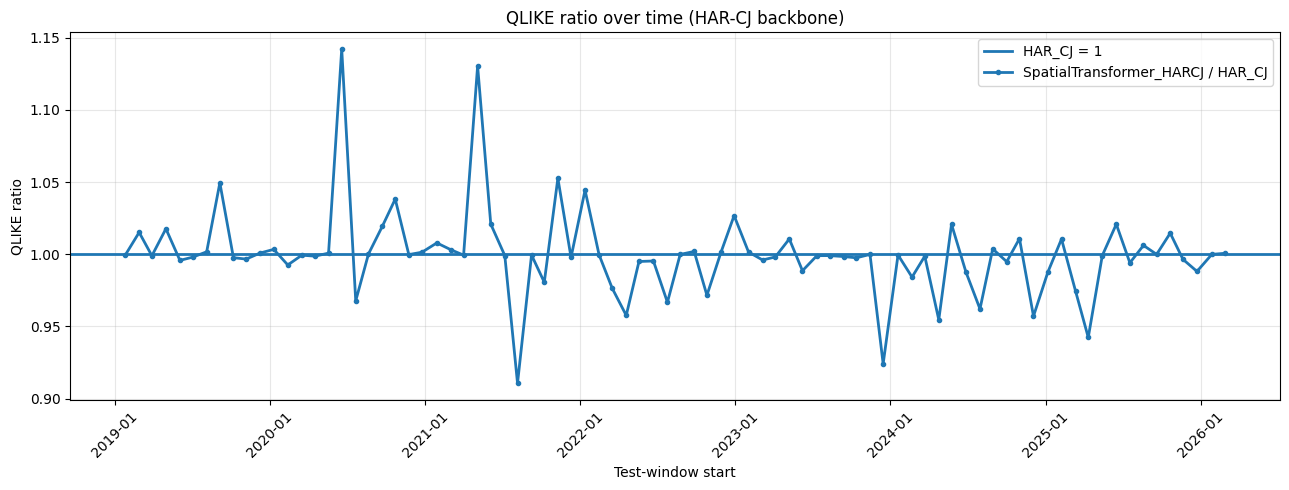


Completato. Risultati in 'risultati'.


In [ ]:
"""
Spatial Transformer HAR-CJ
==========================
Rolling realized-volatility forecasting pipeline.

Architecture
------------
Pooled econometric HAR-CJ anchor (QLIKE, L-BFGS-B) multiplied by a
bounded correction learned by a single-head sparse Transformer:

    RV_hat[i,t] = HAR_CJ[i,t] * M[i,t],   M[i,t] ∈ [0.80, 1.50]

The Transformer builds a directed latent graph over N assets and aggregates
cross-sectional spillover information into a scalar correction signal.

Key design choices
------------------
- Single attention head: adjacency = attention directly, no averaging across
  heads that would inflate the graph degree.
- Sparsemax instead of softmax: produces exact zeros for weak connections,
  giving a natively sparse graph without post-hoc thresholding.
- Learnable temperature τ > 1: amplifies score differences before Sparsemax,
  controlling sparsity during training.
- IPR edge penalty: Inverse Participation Ratio penalises weight dispersion
  across neighbours; scale-invariant in [1/N, 1] regardless of N.
- Quantile gate: reduces the GNN contribution when lagged volatility enters
  empirical tail states, protecting against out-of-distribution shocks.

Feature layout  (T, N, 7)
--------------------------
  0  C_D   daily continuous component   (BV_{t-1})
  1  C_W   weekly continuous component
  2  C_M   monthly continuous component
  3  J_D   daily jump component
  4  J_W   weekly jump component
  5  J_M   monthly jump component
  6  Ret   lagged log-return r_{t-1}

HAR-CJ backbone uses features 0–5; the Transformer branch uses all 7.

Graph convention
----------------
adj[b, i, j] = attention weight that target i assigns to source j.
Row mass measures incoming spillover; column mass measures outgoing spillover.
"""

import warnings
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities, modularity

warnings.filterwarnings("ignore")


# ==============================================================================
# 0. Device and reproducibility
# ==============================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ==============================================================================
# 1. Losses and metrics
# ==============================================================================

def qlike_loss_torch(y_true: torch.Tensor,
                     y_pred: torch.Tensor,
                     eps: float = 1e-10) -> torch.Tensor:
    """QLIKE loss — robust to heteroskedasticity, standard for volatility."""
    y_true = torch.clamp(y_true, min=eps)
    y_pred = torch.clamp(y_pred, min=eps)
    ratio  = y_true / y_pred
    return torch.mean(ratio - torch.log(ratio) - 1.0)


def relative_anchor_loss(pred: torch.Tensor,
                          ref: torch.Tensor,
                          eps: float = 1e-10) -> torch.Tensor:
    """Penalise relative deviation from the HAR-CJ anchor.
    Prevents the Transformer from drifting far from the econometric baseline."""
    ref = torch.clamp(ref, min=eps)
    return torch.mean(((pred - ref) / ref) ** 2)


def compute_metrics(y_true, y_pred, y_prev_ref, eps: float = 1e-10):
    """Return MSE, MAE, QLIKE, TIC, directional accuracy."""
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), eps)

    mse   = mean_squared_error(y_true, y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    ratio = y_true / y_pred
    qlike = np.mean(ratio - np.log(ratio) - 1.0)
    rmse  = np.sqrt(mse)
    denom = np.sqrt(np.mean(y_true ** 2)) + np.sqrt(np.mean(y_pred ** 2))
    tic   = rmse / denom if denom > 0 else np.nan

    y_prev_ref = max(float(y_prev_ref), eps)
    y_true_ext = np.concatenate(([y_prev_ref], y_true))
    y_pred_ext = np.concatenate(([y_prev_ref], y_pred))
    da = np.mean(np.sign(np.diff(y_true_ext)) == np.sign(np.diff(y_pred_ext)))

    return mse, mae, qlike, tic, da


# ==============================================================================
# 2. Graph diagnostics
# ==============================================================================

def graph_diagnostics(adj: torch.Tensor,
                      transformer_block=None,
                      eps: float = 1e-12) -> dict:
    """Compute degree, mass, IPR and attention diagnostics from adj (B, N, N)."""
    with torch.no_grad():
        row_mass        = adj.sum(dim=-1)
        col_mass        = adj.sum(dim=-2)
        hard_in_degree  = (adj > eps).float().sum(dim=-1)
        hard_out_degree = (adj > eps).float().sum(dim=-2)

        p         = (adj / (row_mass.unsqueeze(-1) + eps)).clamp(min=0.0)
        non_empty = row_mass > eps
        ipr       = 1.0 / (p.pow(2).sum(dim=-1) + eps)
        ipr       = torch.where(non_empty, ipr, torch.zeros_like(ipr))
        k_top     = min(3, p.shape[-1])
        top3_mass = p.topk(k=k_top, dim=-1).values.sum(dim=-1)

        out = {
            "Graph_Row_Mass":            row_mass.mean().item(),
            "Graph_Column_Mass":         col_mass.mean().item(),
            "Graph_Test_Avg_In_Degree":  hard_in_degree.mean().item(),
            "Graph_Test_Avg_Out_Degree": hard_out_degree.mean().item(),
            "Graph_IPR_Degree":          ipr.mean().item(),
            "Graph_Max_Weight":          p.max(dim=-1).values.mean().item(),
            "Graph_Top3_Mass":           top3_mass.mean().item(),
        }
        if transformer_block is not None:
            out.update({
                "Attn_Entropy_Norm": transformer_block.last_attn_entropy_norm,
                "Attn_Max":          transformer_block.last_attn_max,
                "Attn_Sparsity":     transformer_block.last_attn_sparsity,
                "Attn_Temperature":  transformer_block.last_temperature,
                "Attn_IPR":          transformer_block.last_ipr,
            })
        return out


# ==============================================================================
# 3. Feature scaling
# ==============================================================================

def fit_feature_scaler(X_raw: torch.Tensor, eps: float = 1e-8):
    mean = X_raw.mean(dim=(0, 1), keepdim=True)
    std  = X_raw.std(dim=(0, 1), keepdim=True, unbiased=False).clamp(min=eps)
    return mean, std


def transform_features(X_raw: torch.Tensor, mean, std,
                        clip_value: float = 9.0) -> torch.Tensor:
    X = (X_raw - mean) / std
    return torch.clamp(X, min=-clip_value, max=clip_value) if clip_value else X


# ==============================================================================
# 4. Weighted directed graph analysis
# ==============================================================================

def _offdiag(A):
    A = np.asarray(A, dtype=float)
    return A[~np.eye(A.shape[0], dtype=bool)]

def weighted_jaccard(A, B, eps=1e-12):
    a, b  = np.maximum(_offdiag(A), 0.), np.maximum(_offdiag(B), 0.)
    denom = np.maximum(a, b).sum()
    return float(np.minimum(a, b).sum() / denom) if denom > eps else np.nan

def cosine_sim(A, B, eps=1e-12):
    a, b  = _offdiag(A), _offdiag(B)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > eps else np.nan

def topk_sets(A, k=3):
    A, n  = np.asarray(A, float), A.shape[0]
    out   = []
    for i in range(n):
        row = A[i].copy(); row[i] = -np.inf
        idx = np.argsort(row)[-min(k, n-1):]
        out.append({j for j in idx if row[j] > 0})
    return out

def topk_overlap(A, B, k=3):
    sa, sb, ol = topk_sets(A, k), topk_sets(B, k), []
    for Sa, Sb in zip(sa, sb):
        if not Sa and not Sb: continue
        ol.append(len(Sa & Sb) / max(min(k, len(Sa | Sb)), 1))
    return float(np.mean(ol)) if ol else np.nan

def effective_degree(A, eps=1e-12):
    A   = np.asarray(A, float)
    rs  = A.sum(axis=1, keepdims=True)
    P   = np.maximum(A / (rs + eps), 0.)
    k   = 1.0 / (np.sum(P**2, axis=1) + eps)
    return np.where(rs.squeeze() > eps, k, 0.)

def top_mass(A, k=3, eps=1e-12):
    A   = np.asarray(A, float)
    rs  = A.sum(axis=1, keepdims=True)
    P   = np.maximum(A / (rs + eps), 0.)
    return float(np.sort(P, axis=1)[:, -min(k, A.shape[1]):].sum(axis=1).mean())

def build_graph(A, tickers, top_k=5, eps=1e-12):
    A, n = np.asarray(A, float), len(tickers)
    G    = nx.DiGraph(); G.add_nodes_from(tickers)
    for i in range(n):
        row = A[i].copy(); row[i] = 0.
        pos = np.where(row > eps)[0]
        if not len(pos): continue
        for j in pos[np.argsort(row[pos])[-min(top_k, len(pos)):]]:
            G.add_edge(tickers[j], tickers[i],
                       weight=float(row[j]), distance=1./(float(row[j]) + eps))
    return G

def _fmt(items, d=4):
    return ", ".join(f"{n} ({v:.{d}f})" for n, v in items)


def analyze_latent_graphs(adjacency_test_matrices: dict, tickers: list,
                          top_k_sources: int = 3, top_k_graph: int = 5):
    """Summarise time-varying latent graphs: stability, centrality, communities."""
    graph_rows, node_rows, all_means, prev = [], [], [], None

    for date, adj_3d in adjacency_test_matrices.items():
        adj_3d = np.asarray(adj_3d, float)
        Am     = adj_3d.mean(axis=0); np.fill_diagonal(Am, 0.)
        all_means.append(Am)

        row_m = Am.sum(axis=1); col_m = Am.sum(axis=0)
        ed    = effective_degree(Am); tm = top_mass(Am, top_k_sources)

        wj, cs, to = [], [], []
        for t in range(1, adj_3d.shape[0]):
            Ap = adj_3d[t-1].copy(); np.fill_diagonal(Ap, 0.)
            Ac = adj_3d[t].copy();   np.fill_diagonal(Ac, 0.)
            wj.append(weighted_jaccard(Ac, Ap))
            cs.append(cosine_sim(Ac, Ap))
            to.append(topk_overlap(Ac, Ap, top_k_sources))

        r_wj = r_cs = r_to = np.nan
        if prev is not None:
            r_wj = weighted_jaccard(Am, prev)
            r_cs = cosine_sim(Am, prev)
            r_to = topk_overlap(Am, prev, top_k_sources)
        prev = Am

        G = build_graph(Am, tickers, top_k_graph)
        if G.number_of_edges() > 0:
            btw   = nx.betweenness_centrality(G, weight="distance", normalized=True)
            Gu    = G.to_undirected()
            clust = nx.average_clustering(Gu, weight="weight")
            comms = list(greedy_modularity_communities(Gu, weight="weight"))
            modul = modularity(Gu, comms, weight="weight")
            clabels = {nd: c+1 for c, cm in enumerate(comms) for nd in cm}
        else:
            btw   = {t: 0. for t in tickers}
            clust = modul = np.nan; comms = []; clabels = {t: np.nan for t in tickers}

        graph_rows.append({
            "date_test_start":                           pd.to_datetime(date),
            "Graph_Row_Mass":                            float(row_m.mean()),
            "Graph_Column_Mass":                         float(col_m.mean()),
            "Graph_Effective_Degree":                    float(ed.mean()),
            f"Graph_Top{top_k_sources}_Mass":            float(tm),
            "Graph_Within_Weighted_Jaccard":             float(np.nanmean(wj)),
            "Graph_Within_Cosine":                       float(np.nanmean(cs)),
            f"Graph_Within_Top{top_k_sources}_Overlap":  float(np.nanmean(to)),
            "Graph_Rolling_Weighted_Jaccard":            r_wj,
            "Graph_Rolling_Cosine":                      r_cs,
            f"Graph_Rolling_Top{top_k_sources}_Overlap": r_to,
            "Graph_Avg_Clustering":                      clust,
            "Graph_Num_Communities":                     len(comms),
            "Graph_Modularity":                          modul,
            "Top5_Receivers":    _fmt(sorted(zip(tickers, row_m), key=lambda x: x[1], reverse=True)[:5]),
            "Top5_Transmitters": _fmt(sorted(zip(tickers, col_m), key=lambda x: x[1], reverse=True)[:5]),
            "Top5_Bridges":      _fmt(sorted(btw.items(), key=lambda x: x[1], reverse=True)[:5]),
        })
        for i, tk in enumerate(tickers):
            node_rows.append({
                "date_test_start": pd.to_datetime(date), "symbol": tk,
                "in_strength":     float(row_m[i]), "out_strength": float(col_m[i]),
                "effective_degree":float(ed[i]),    "betweenness":  float(btw.get(tk, 0.)),
                "community":       clabels.get(tk, np.nan),
            })

    gs = pd.DataFrame(graph_rows); ni = pd.DataFrame(node_rows)
    if not all_means:
        return gs, ni, pd.DataFrame()

    Ag   = np.mean(np.stack(all_means), axis=0); np.fill_diagonal(Ag, 0.)
    Gu_g = build_graph(Ag, tickers, top_k_graph).to_undirected()
    gc   = (list(greedy_modularity_communities(Gu_g, weight="weight"))
            if Gu_g.number_of_edges() > 0 else [])
    ac   = pd.DataFrame([{"community": f"Cluster_{c+1}",
                          "size": len(cm), "members": ", ".join(sorted(cm))}
                         for c, cm in enumerate(gc)])
    return gs, ni, ac


def print_graph_report(gs, ni, ac):
    sep = "=" * 90
    print(f"\n{sep}\nLATENT ATTENTION GRAPH — GLOBAL DIAGNOSTICS\n{sep}")
    cols  = ["Graph_Row_Mass", "Graph_Column_Mass", "Graph_Effective_Degree",
             "Graph_Top3_Mass", "Graph_Within_Weighted_Jaccard",
             "Graph_Rolling_Weighted_Jaccard",
             "Graph_Avg_Clustering", "Graph_Num_Communities", "Graph_Modularity"]
    avail = [c for c in cols if c in gs.columns]
    print(gs[avail].mean(numeric_only=True).to_string() if avail else "N/A")
    for lbl, col in [("TOP 5 RECEIVERS",    "in_strength"),
                     ("TOP 5 TRANSMITTERS", "out_strength"),
                     ("TOP 5 BRIDGES",      "betweenness")]:
        print(f"\n{sep}\n{lbl}\n{sep}")
        print(ni.groupby("symbol")[col].mean().sort_values(ascending=False).head(5).to_string())
    print(f"\n{sep}\nCOMMUNITIES\n{sep}")
    print("No stable communities." if ac.empty else ac.to_string(index=False))


# ==============================================================================
# 5. Sparse attention module
# ==============================================================================

class Sparsemax(nn.Module):
    """Projects scores onto the probability simplex — exact zeros for weak edges."""
    def __init__(self, dim: int = -1):
        super().__init__()
        self.dim = dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x      = x - x.max(dim=self.dim, keepdim=True).values
        zs     = torch.sort(x, dim=self.dim, descending=True).values
        rng    = torch.arange(1, x.size(self.dim) + 1,
                              device=x.device, dtype=x.dtype).expand_as(zs)
        bound  = 1 + rng * zs
        cumsum = torch.cumsum(zs, dim=self.dim)
        k      = ((bound > cumsum).float() * rng).max(dim=self.dim, keepdim=True).values.long()
        tau    = (torch.gather(cumsum, self.dim, k - 1) - 1) / k.float()
        return torch.clamp(x - tau, min=0.0)


class SingleHeadSparseAttention(nn.Module):
    """
    Single-head sparse attention over N assets.

    Why single head?
    ----------------
    Multi-head attention averages H attention matrices to form the graph.
    Even if each head is sparse, the average has up to H times more active
    edges — defeating the purpose of sparsity. With one head the adjacency
    equals the attention directly, preserving whatever sparsity Sparsemax
    and temperature impose.
    Expressiveness is maintained by using a larger head_dim (e.g. 32).

    Sparsity levers
    ---------------
    - Sparsemax:    exact zeros for weak connections.
    - Temperature τ > 1: amplifies score differences before Sparsemax,
                    making the distribution more peaked → fewer active edges.
                    τ is a scalar learnable parameter (softplus-constrained).
    """
    def __init__(self, n_assets: int, in_features: int,
                 head_dim: int = 32, dropout_p: float = 0.1,
                 init_temperature: float = 2.0):
        super().__init__()
        self.scale = np.sqrt(head_dim)

        self.W_Q = nn.Linear(in_features, head_dim, bias=False)
        self.W_K = nn.Linear(in_features, head_dim, bias=False)
        self.W_V = nn.Linear(in_features, head_dim, bias=False)
        self.W_O = nn.Linear(head_dim, head_dim)

        # Structural asset bias: each asset has a fixed receiver (Q) and
        # transmitter (K) role, analogous to source/target embeddings in GNNs.
        self.query_bias = nn.Parameter(torch.randn(n_assets, head_dim) * 0.01)
        self.key_bias   = nn.Parameter(torch.randn(n_assets, head_dim) * 0.01)

        # Learnable temperature τ > 1 (softplus ensures positivity; +1 ensures > 1).
        raw_init = float(np.log(np.exp(max(init_temperature - 1., 1e-4)) - 1.))
        self.raw_temperature = nn.Parameter(torch.tensor(raw_init))

        self.attn_dropout = nn.Dropout(dropout_p)
        self.sparsemax    = Sparsemax(dim=-1)

        # Self-attention is meaningless — mask the diagonal.
        self.register_buffer("diag_mask",
                             torch.eye(n_assets, dtype=torch.bool).unsqueeze(0))

    @property
    def temperature(self) -> torch.Tensor:
        return 1.0 + F.softplus(self.raw_temperature)

    def forward(self, x: torch.Tensor):
        B, N, _ = x.shape
        Q = self.W_Q(x) + self.query_bias[:N]   # (B, N, D)
        K = self.W_K(x) + self.key_bias[:N]     # (B, N, D)
        V = self.W_V(x)                          # (B, N, D)

        # Higher τ → more peaked scores → Sparsemax assigns zeros to more nodes.
        scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale * self.temperature
        scores = scores.masked_fill(self.diag_mask[:, :N, :N], -1e9)

        attn = self.sparsemax(scores)            # (B, N, N) — exact zeros
        attn = self.attn_dropout(attn)

        out  = self.W_O(torch.bmm(attn, V))     # (B, N, D)
        return out, attn


class SpatialTransformerBlock(nn.Module):
    """
    Single-head sparse attention + position-wise FFN.

    edge_penalty: -IPR (Inverse Participation Ratio)
    -------------------------------------------------
    IPR_i = Σ_j p_ij²  ∈ [1/N, 1]
      IPR = 1   → all weight on one node (maximally sparse)
      IPR = 1/N → uniform distribution (dense graph)

    Minimising -IPR = maximising concentration = sparser graph.
    IPR is scale-invariant in [1/N, 1] regardless of N, unlike entropy
    which scales with log(N). This makes lambda_edges comparable across
    datasets with different numbers of assets.

    Entropy is still tracked as a normalised diagnostic (divided by log N).
    """
    def __init__(self, n_assets: int, in_features: int = 7,
                 head_dim: int = 32, ffn_expand: int = 2,
                 dropout_p: float = 0.15, out_dim: int = 8,
                 init_temperature: float = 2.0):
        super().__init__()

        self.attn       = SingleHeadSparseAttention(
            n_assets, in_features, head_dim, dropout_p, init_temperature)
        self.ln_attn    = nn.LayerNorm(in_features)
        self.input_proj = nn.Linear(in_features, head_dim, bias=False)

        self.ln_ffn = nn.LayerNorm(head_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(head_dim, head_dim * ffn_expand),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(head_dim * ffn_expand, head_dim),
            nn.Dropout(dropout_p),
        )
        self.ln_out   = nn.LayerNorm(head_dim)
        self.out_proj = nn.Linear(head_dim, out_dim)

        # Diagnostics updated each forward pass.
        self.edge_penalty            = torch.tensor(0.0)
        self.last_attn_entropy_norm  = 0.0
        self.last_attn_max           = 0.0
        self.last_attn_sparsity      = 0.0
        self.last_temperature        = float(init_temperature)
        self.last_ipr                = 0.0

    def forward(self, x: torch.Tensor, hard_threshold: float = None):
        """
        Parameters
        ----------
        x              : (B, N, in_features)
        hard_threshold : if set, zero adj weights below this at test time
                         (only affects the stored adjacency, not the aggregation).

        Returns
        -------
        out : (B, N, out_dim)
        adj : (B, N, N)  implicit directed graph (= sparse attention)
        """
        x_proj   = self.input_proj(x)
        attn_out, attn = self.attn(self.ln_attn(x))   # attn: (B, N, N)
        h  = x_proj + attn_out
        h  = h + self.ffn(self.ln_ffn(h))
        out = self.out_proj(self.ln_out(h))

        # adjacency = attention (no multi-head average needed)
        adj = attn
        if hard_threshold is not None:
            adj = adj.masked_fill(adj < hard_threshold, 0.0)

        # IPR: concentration metric, scale-invariant in [1/N, 1].
        ipr = attn.pow(2).sum(dim=-1).mean()
        self.edge_penalty = -ipr    # minimising pushes toward sparser graphs

        with torch.no_grad():
            N   = attn.shape[-1]
            eps = 1e-10
            # Entropy normalised by log(N): scale-invariant in [0, 1].
            raw_H = -(attn * (attn + eps).log()).sum(dim=-1).mean()
            self.last_attn_entropy_norm = (raw_H / np.log(max(N, 2))).item()
            self.last_attn_max          = attn.max().item()
            self.last_attn_sparsity     = (attn < 1e-9).float().mean().item()
            self.last_temperature       = self.attn.temperature.item()
            self.last_ipr               = ipr.item()

        return out, adj


# ==============================================================================
# 6. HAR-CJ + Transformer model
# ==============================================================================

class LatentSpatialTransformerHARCJ(nn.Module):
    """
    Pooled HAR-CJ econometric anchor multiplied by a Transformer correction.

        RV_hat[i,t] = HAR_CJ[i,t]  *  M[i,t]
        M[i,t]      = clip(1 + σ(s) * ω[i,t] * c[i,t], M_min, M_max)

    where:
        σ(s)    = global spillover scale (learnable)
        ω[i,t]  = quantile gate ∈ [floor, 1]  (shrinks in tail states)
        c[i,t]  = softsign-compressed Transformer output

    The network never re-estimates HAR-CJ; it only learns a relative correction.
    """
    def __init__(
        self,
        n_assets:              int,
        in_features:           int   = 7,
        head_dim:              int   = 32,
        ffn_expand:            int   = 2,
        out_dim:               int   = 8,
        init_temperature:      float = 2.0,
        min_var:               float = 1e-10,
        dropout_p:             float = 0.15,
        init_spill_logit:      float = -2.0,
        min_gnn_multiplier:    float = 0.80,
        max_gnn_multiplier:    float = 1.50,
        correction_mode:       str   = "softsign",
        spill_clip:            float = 5.0,
        softsign_scale:        float = 3.0,
        quantile_shrink_floor: float = 0.60,
        quantile_power:        float = 1.0,
        quantile_tail_start:   float = 0.90,
    ):
        super().__init__()
        self.min_var            = min_var
        self.min_gnn_multiplier = min_gnn_multiplier
        self.max_gnn_multiplier = max_gnn_multiplier
        self.correction_mode    = correction_mode.lower()
        self.spill_clip         = spill_clip
        self.softsign_scale     = softsign_scale

        # Quantile gate: only log(RV_d) drives the gate.
        # Theoretical justification: it is the most direct indicator of
        # whether the current market state is in-distribution relative to
        # the training window. Jump share and returns add noise.
        self.quantile_shrink_floor = quantile_shrink_floor
        self.quantile_power        = quantile_power
        self.quantile_tail_start   = quantile_tail_start
        self.register_buffer("quantile_reference", torch.empty(0, dtype=torch.float32))

        # Diagnostics (updated each forward pass).
        self.last_quantile_shrink        = float("nan")
        self.last_quantile_extreme       = float("nan")
        self.last_effective_gnn_scale    = float("nan")
        self.last_multiplier_mean        = float("nan")
        self.last_multiplier_min         = float("nan")
        self.last_multiplier_max         = float("nan")
        self.last_abs_rel_correction     = float("nan")
        self.last_max_abs_rel_correction = float("nan")
        self.last_correction_signal_mean = float("nan")

        self.spatial_transformer = SpatialTransformerBlock(
            n_assets=n_assets, in_features=in_features, head_dim=head_dim,
            ffn_expand=ffn_expand, dropout_p=dropout_p,
            out_dim=out_dim, init_temperature=init_temperature,
        )
        self.readout     = nn.Linear(out_dim, 1, bias=False)
        nn.init.normal_(self.readout.weight, mean=0.0, std=1e-3)
        self.spill_scale = nn.Parameter(torch.tensor(float(init_spill_logit)))

    # ── Quantile gate ─────────────────────────────────────────────────────────

    def _quantile_feature(self, x_raw: torch.Tensor) -> torch.Tensor:
        """log(RV_d) = log(C_D + J_D) — lagged daily total variance."""
        c_d  = x_raw[:, :, 0]; j_d = x_raw[:, :, 3]
        rv_d = torch.clamp(c_d + j_d, min=self.min_var)
        return torch.log(rv_d).unsqueeze(-1)   # (B, N, 1)

    def set_quantile_reference(self, X_raw_reference: torch.Tensor) -> None:
        """Store empirical reference distribution for the current rolling window."""
        with torch.no_grad():
            qref = self._quantile_feature(
                X_raw_reference.to(self.spill_scale.device)).detach()
            self.quantile_reference = qref

    def _quantile_gate(self, x_raw: torch.Tensor):
        """Return (node_shrink, node_extreme) both in [0, 1], shape (B, N)."""
        if self.quantile_reference.numel() == 0:
            b, n, _ = x_raw.shape
            return (torch.ones(b, n, device=x_raw.device),
                    torch.zeros(b, n, device=x_raw.device))

        cur = self._quantile_feature(x_raw)            # (B, N, 1)
        ref = self.quantile_reference.to(cur.device)   # (T_ref, N, 1)

        # Empirical CDF: fraction of reference values ≤ current value.
        q   = (ref.unsqueeze(0) <= cur.unsqueeze(1)).float().mean(dim=1).clamp(0, 1)
        raw = 2.0 * torch.abs(q - 0.5)                # [0, 1]: 0 = median, 1 = extreme

        # Shift: gate activates only in the empirical tails.
        ts  = min(max(self.quantile_tail_start, 0.), 0.999)
        ext = ((raw - ts) / max(1. - ts, 1e-6)).clamp(0, 1).squeeze(-1)   # (B, N)

        shrink = (self.quantile_shrink_floor
                  + (1. - self.quantile_shrink_floor) * (1. - ext).pow(self.quantile_power))
        return shrink.clamp(self.quantile_shrink_floor, 1.), ext

    # ── Forward ───────────────────────────────────────────────────────────────

    def forward(self, x_raw: torch.Tensor, x_scaled: torch.Tensor,
                har_anchor: torch.Tensor, hard_threshold: float = None):
        har         = torch.clamp(har_anchor, min=self.min_var)
        spill, adj  = self.spatial_transformer(x_scaled, hard_threshold=hard_threshold)
        spill       = self.readout(spill).squeeze(-1)

        if self.correction_mode == "softsign":
            cs = spill / (1.0 + torch.abs(spill) / max(self.softsign_scale, 1e-6))
        elif self.correction_mode == "tanh":
            cs = torch.tanh(spill)
        else:
            cs = spill

        if self.spill_clip:
            cs = torch.clamp(cs, -self.spill_clip, self.spill_clip)

        scale = torch.sigmoid(self.spill_scale)
        qs, qe = self._quantile_gate(x_raw)

        multiplier = torch.clamp(
            1.0 + scale * qs * cs,
            self.min_gnn_multiplier, self.max_gnn_multiplier)
        pred = torch.clamp(har * multiplier, min=self.min_var)

        with torch.no_grad():
            r = multiplier - 1.0
            self.last_quantile_shrink        = qs.mean().item()
            self.last_quantile_extreme       = qe.mean().item()
            self.last_effective_gnn_scale    = (scale * qs).mean().item()
            self.last_multiplier_mean        = multiplier.mean().item()
            self.last_multiplier_min         = multiplier.min().item()
            self.last_multiplier_max         = multiplier.max().item()
            self.last_abs_rel_correction     = r.abs().mean().item()
            self.last_max_abs_rel_correction = r.abs().max().item()
            self.last_correction_signal_mean = cs.mean().item()

        return pred, har, adj


# ==============================================================================
# 7. Data preparation
# ==============================================================================

def prepare_data(df_filtered, log_returns,
                 rv_col: str = "rv5_ss", bv_col: str = "bv5_ss"):
    """Build RV, BV, jump and return pivots from long-format input."""
    df = df_filtered.copy(); rets = log_returns.copy()
    df["date"]  = pd.to_datetime(df["date"])
    rets.index  = pd.to_datetime(rets.index)
    df["j"]     = np.maximum(df[rv_col] - df[bv_col], 0.)

    def pivot(col):
        return (df.pivot(index="date", columns="symbol", values=col)
                .sort_index(axis=0).sort_index(axis=1)
                .replace([np.inf, -np.inf], np.nan).ffill().dropna(how="any"))

    rv, bv, jp = pivot(rv_col), pivot(bv_col), pivot("j")
    idx = rv.index.intersection(bv.index).intersection(jp.index)
    rv, bv, jp = rv.loc[idx], bv.loc[idx], jp.loc[idx]
    ret = (rets.reindex(index=rv.index, columns=rv.columns)
           .sort_index(axis=0).sort_index(axis=1)
           .replace([np.inf, -np.inf], np.nan))
    return rv, bv, jp, ret


def build_features(rv, bv, jp, variant: str = "disjoint"):
    """Build disjoint (non-overlapping) or standard HAR-CJ lags."""
    if variant == "disjoint":
        c_d = bv.shift(1);         c_w = bv.shift(2).rolling(4).mean()
        c_m = bv.shift(6).rolling(17).mean()
        j_d = jp.shift(1);         j_w = jp.shift(2).rolling(4).mean()
        j_m = jp.shift(6).rolling(17).mean()
    elif variant == "standard":
        c_d = bv.shift(1);         c_w = bv.shift(1).rolling(5).mean()
        c_m = bv.shift(1).rolling(22).mean()
        j_d = jp.shift(1);         j_w = jp.shift(1).rolling(5).mean()
        j_m = jp.shift(1).rolling(22).mean()
    else:
        raise ValueError("variant must be 'disjoint' or 'standard'.")
    valid = c_m.dropna(how="any").index.intersection(j_m.dropna(how="any").index)
    return (rv.loc[valid], c_d.loc[valid], c_w.loc[valid], c_m.loc[valid],
            j_d.loc[valid], j_w.loc[valid], j_m.loc[valid])


def to_tensors(rv, c_d, c_w, c_m, j_d, j_w, j_m, ret, dates):
    """Stack features into (T, N, 7) tensor; target is RV (T, N)."""
    X = np.stack([c_d.loc[dates].values, c_w.loc[dates].values,
                  c_m.loc[dates].values, j_d.loc[dates].values,
                  j_w.loc[dates].values, j_m.loc[dates].values,
                  ret.loc[dates].values], axis=-1).astype(float)
    y = rv.loc[dates].values.astype(float)
    return (torch.tensor(np.nan_to_num(X, 0.), dtype=torch.float32),
            torch.tensor(np.nan_to_num(y, 0.), dtype=torch.float32))


def check_no_leakage(ret_lagged, ret_raw) -> None:
    """Assert that ret_lagged[t] == ret_raw[t-1] for all t."""
    expected = ret_raw.shift(1).loc[ret_lagged.index, ret_lagged.columns]
    if not np.allclose(ret_lagged.values.astype(float),
                       expected.values.astype(float), equal_nan=True):
        raise ValueError("Return leakage detected: ret is not aligned as r_{t-1}.")


def make_loader(X_raw, X_sc, har, y, batch_size=32, shuffle=True):
    return DataLoader(TensorDataset(X_raw, X_sc, har, y),
                      batch_size=batch_size, shuffle=shuffle,
                      drop_last=False, num_workers=0, pin_memory=False)

def to_device(batch):
    return tuple(t.to(device) for t in batch)


# ==============================================================================
# 8. Pooled HAR-CJ econometric anchor
# ==============================================================================

def _harcj_qlike(params, X, y, ti, N, eps=1e-10):
    alphas, betas = params[:N], params[N:]
    y_hat = np.maximum(alphas[ti] + X @ betas, eps)
    r     = np.maximum(y, eps) / y_hat
    return float(np.mean(r - np.log(r) - 1.0))


def fit_harcj(X_raw, y, min_var=1e-10):
    """Estimate pooled HAR-CJ via QLIKE / L-BFGS-B on the current window."""
    X_np = X_raw[:, :, :6].detach().cpu().numpy().astype(float)
    y_np = y.detach().cpu().numpy().astype(float)
    T, N, _ = X_np.shape
    Xf = X_np.reshape(T*N, 6); yf = y_np.reshape(T*N)
    ti = np.tile(np.arange(N), T)
    ok = np.isfinite(Xf).all(1) & np.isfinite(yf)
    Xf, yf, ti = Xf[ok], yf[ok], ti[ok]
    a0  = np.maximum(np.nanmean(y_np, axis=0) * 0.10, min_var)
    p0  = np.concatenate([a0, [0.15]*6])
    bnd = [(min_var, None)]*N + [(0., None)]*6
    res = minimize(_harcj_qlike, p0, args=(Xf, yf, ti, N, min_var),
                   method="L-BFGS-B", bounds=bnd,
                   options={"maxiter": 1000, "ftol": 1e-12})
    return res.x if res.success and np.all(np.isfinite(res.x)) else p0


def predict_harcj(X_raw, params, min_var=1e-10):
    X_np = X_raw[:, :, :6].detach().cpu().numpy().astype(float)
    T, N, _ = X_np.shape
    pred = np.maximum(params[:N].reshape(1, N) +
                      np.einsum("tnf,f->tn", X_np, params[N:]), min_var)
    return torch.tensor(np.nan_to_num(pred, nan=min_var), dtype=torch.float32)


# ==============================================================================
# 9. Rolling pipeline
# ==============================================================================

def run(
    df_filtered,
    log_returns,
    # Rolling scheme
    window:          int   = 22,
    train_size:      int   = 750,
    val_size:        int   = 250,
    max_epochs:      int   = 400,
    patience:        int   = 40,
    smooth_window:   int   = 10,
    har_variant:     str   = "disjoint",
    # Transformer
    head_dim:        int   = 32,    # single head; increase for more expressiveness
    ffn_expand:      int   = 2,
    out_dim:         int   = 8,
    init_temperature:float = 2.0,   # higher → sparser graph
    # Optimisation
    batch_size:      int   = 32,
    lr:              float = 1e-3,
    weight_decay:    float = 5e-4,
    grad_clip:       float = 1.0,
    # Loss weights
    lambda_anchor:   float = 0.05,
    lambda_edges:    float = 0.05,  # penalises -IPR → sparser graph
    # Correction
    dropout_p:       float = 0.15,
    init_spill_logit:float = -2.0,
    min_multiplier:  float = 0.80,
    max_multiplier:  float = 1.50,
    correction_mode: str   = "softsign",
    spill_clip:      float = 5.0,
    softsign_scale:  float = 3.0,
    # Quantile gate
    shrink_floor:    float = 0.60,
    quantile_power:  float = 1.0,
    tail_start:      float = 0.90,
    # Misc
    feature_clip:    float = 6.0,
    test_threshold:  float = 0.02,  # edges below this zeroed in adj for analysis
    min_var_floor:   float = 1e-10,
    min_var_pct:     float = 0.1,
    min_var_scale:   float = 0.1,
    seed:            int   = 1234,
    model_tag:       str   = "SpatialTransformer_HARCJ",
    baseline_tag:    str   = "HAR_CJ",
    rv_col:          str   = "rv5_ss",
    bv_col:          str   = "bv5_ss",
):
    set_seed(seed)

    rv_raw, bv_raw, j_raw, ret_raw = prepare_data(
        df_filtered, log_returns, rv_col, bv_col)
    rv, c_d, c_w, c_m, j_d, j_w, j_m = build_features(
        rv_raw, bv_raw, j_raw, har_variant)

    ret       = ret_raw.shift(1).loc[rv.index]
    valid     = ret.dropna(how="any").index
    rv  = rv.loc[valid];   c_d = c_d.loc[valid]; c_w = c_w.loc[valid]
    c_m = c_m.loc[valid];  j_d = j_d.loc[valid]; j_w = j_w.loc[valid]
    j_m = j_m.loc[valid];  ret = ret.loc[valid]
    check_no_leakage(ret, ret_raw)

    dates, tickers = list(rv.index), list(rv.columns)
    N             = len(tickers)
    total         = train_size + val_size
    max_start     = len(dates) - total - window + 1
    if max_start <= 0:
        raise ValueError("Insufficient data for train/val/test split.")

    results, baselines, adj_store = [], [], {}

    def _tens(d):
        return to_tensors(rv, c_d, c_w, c_m, j_d, j_w, j_m, ret, d)

    def _model(mv):
        return LatentSpatialTransformerHARCJ(
            n_assets=N, in_features=7, head_dim=head_dim,
            ffn_expand=ffn_expand, out_dim=out_dim,
            init_temperature=init_temperature, min_var=mv,
            dropout_p=dropout_p, init_spill_logit=init_spill_logit,
            min_gnn_multiplier=min_multiplier, max_gnn_multiplier=max_multiplier,
            correction_mode=correction_mode, spill_clip=spill_clip,
            softsign_scale=softsign_scale, quantile_shrink_floor=shrink_floor,
            quantile_power=quantile_power, quantile_tail_start=tail_start,
        ).to(device)

    def _train(model, loader, n_ep, sched_type):
        opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = (optim.lr_scheduler.ReduceLROnPlateau(
                     opt, mode="min", factor=0.5, patience=15)
                 if sched_type == "plateau"
                 else optim.lr_scheduler.CosineAnnealingLR(
                     opt, T_max=max(n_ep, 1), eta_min=1e-6))
        vlosses, best, no_imp = [], np.inf, 0

        for _ in range(n_ep):
            model.train()
            for batch in loader:
                bx, bxs, bh, by = to_device(batch)
                opt.zero_grad(set_to_none=True)
                pred, har, _ = model(bx, bxs, bh)
                loss = (qlike_loss_torch(by, pred, model.min_var)
                        + lambda_anchor * relative_anchor_loss(pred, har, model.min_var)
                        + lambda_edges  * model.spatial_transformer.edge_penalty)
                loss.backward()
                if grad_clip: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                opt.step()

            if sched_type == "plateau":
                model.eval()
                with torch.no_grad():
                    pv, _, _ = model(Xvr, Xvs, hvd)
                    vl = qlike_loss_torch(yvd, pv, model.min_var).item()
                vlosses.append(vl); sched.step(vl)
                if vl < best: best, no_imp = vl, 0
                else: no_imp += 1
                if no_imp >= patience: break
            else:
                sched.step()
        return vlosses, best

    for rid, si in enumerate(tqdm(range(0, max_start, window),
                                  desc=f"Rolling [{model_tag}]")):
        tr_d  = dates[si : si+train_size]
        va_d  = dates[si+train_size : si+total]
        co_d  = dates[si : si+total]
        te_d  = dates[si+total : si+total+window]
        if not te_d: continue

        hist    = rv.loc[co_d].values.astype(float)
        hist    = hist[np.isfinite(hist)]
        min_var = max(float(np.nanpercentile(hist, min_var_pct) * min_var_scale),
                      min_var_floor) if hist.size else min_var_floor

        # ── Phase 1: select optimal epoch on validation ───────────────────
        Xtr, ytr = _tens(tr_d); Xva, yva = _tens(va_d)
        p1   = fit_harcj(Xtr, ytr, min_var)
        htr  = predict_harcj(Xtr, p1, min_var)
        hva  = predict_harcj(Xva, p1, min_var)
        mu, sg = fit_feature_scaler(Xtr)
        Xts  = transform_features(Xtr, mu, sg, feature_clip)
        Xvs  = transform_features(Xva, mu, sg, feature_clip)

        mdl  = _model(min_var); mdl.set_quantile_reference(Xtr)
        Xvr  = Xva.to(device); Xvs_d = Xvs.to(device)
        hvd  = hva.to(device);  yvd  = yva.to(device)
        # expose validation tensors to _train closure
        Xvr, Xvs, hvd, yvd = Xvr, Xvs_d, hvd, yvd

        vl, bvl = _train(mdl, make_loader(Xtr, Xts, htr, ytr, batch_size), max_epochs, "plateau")
        sm      = pd.Series(vl).rolling(smooth_window, center=True, min_periods=1).mean().values
        opt_ep  = max(1, int(np.nanargmin(sm)) + 1) if len(vl) >= smooth_window else max(1, int(np.nanargmin(vl)) + 1)

        # ── Phase 2: retrain on train+val, test ──────────────────────────
        Xco, yco = _tens(co_d); Xte, yte = _tens(te_d)
        p2  = fit_harcj(Xco, yco, min_var)
        hco = predict_harcj(Xco, p2, min_var)
        hte = predict_harcj(Xte, p2, min_var)
        mc, sc = fit_feature_scaler(Xco)
        Xcos = transform_features(Xco, mc, sc, feature_clip)
        Xtes = transform_features(Xte, mc, sc, feature_clip)

        fm = _model(min_var); fm.set_quantile_reference(Xco)
        Xvr = Xvs = hvd = yvd = None   # not used with cosine schedule
        _train(fm, make_loader(Xco, Xcos, hco, yco, batch_size), opt_ep, "cosine")

        fm.eval()
        with torch.no_grad():
            pr, ho, aj = fm(Xte.to(device), Xtes.to(device),
                            hte.to(device), hard_threshold=test_threshold)
            pnp = pr.cpu().numpy(); hnp = ho.cpu().numpy()
            ynp = yte.numpy();      yco_np = yco.numpy()
            adj_store[te_d[0]] = aj.cpu().numpy().astype(np.float32)

            diag = graph_diagnostics(aj, transformer_block=fm.spatial_transformer)
            ss   = torch.sigmoid(fm.spill_scale).item()
            rdiag = {
                "Quantile_Shrink":        fm.last_quantile_shrink,
                "Quantile_Extreme":       fm.last_quantile_extreme,
                "Effective_Scale":        fm.last_effective_gnn_scale,
                "Multiplier_Mean":        fm.last_multiplier_mean,
                "Multiplier_Min":         fm.last_multiplier_min,
                "Multiplier_Max":         fm.last_multiplier_max,
                "Abs_Rel_Correction":     fm.last_abs_rel_correction,
                "Max_Abs_Rel_Correction": fm.last_max_abs_rel_correction,
            }

        for i, tk in enumerate(tickers):
            m  = compute_metrics(ynp[:,i], pnp[:,i], yco_np[-1,i], min_var)
            bm = compute_metrics(ynp[:,i], hnp[:,i], yco_np[-1,i], min_var)
            row = {"roll_id": rid, "symbol": tk,
                   "date_test_start": te_d[0], "date_test_end": te_d[-1],
                   "n_test_days": len(te_d), "optimal_epoch": opt_ep,
                   "best_val_loss": bvl, "min_var": min_var, "spill_scale": ss,
                   f"MSE_{model_tag}":   m[0], f"MAE_{model_tag}":   m[1],
                   f"QLIKE_{model_tag}": m[2], f"TIC_{model_tag}":   m[3],
                   f"DA_{model_tag}":    m[4]}
            row.update(diag); row.update(rdiag)
            results.append(row)
            baselines.append({"roll_id": rid, "symbol": tk,
                              "date_test_start": te_d[0], "date_test_end": te_d[-1],
                              "n_test_days": len(te_d),
                              f"MSE_{baseline_tag}":   bm[0], f"MAE_{baseline_tag}":   bm[1],
                              f"QLIKE_{baseline_tag}": bm[2], f"TIC_{baseline_tag}":   bm[3],
                              f"DA_{baseline_tag}":    bm[4]})

    return {"results":    pd.DataFrame(results),
            "baselines":  pd.DataFrame(baselines),
            "adj_store":  adj_store,
            "tickers":    tickers}


# ==============================================================================
# 10. Evaluation and plotting
# ==============================================================================

def evaluate(df_m, df_b, model_tag="SpatialTransformer_HARCJ", baseline_tag="HAR_CJ"):
    df_m["date_test_start"] = pd.to_datetime(df_m["date_test_start"])
    df_b["date_test_start"] = pd.to_datetime(df_b["date_test_start"])
    comp = pd.merge(df_m, df_b, on=["symbol","date_test_start"],
                    how="inner", suffixes=("_M","_B"))
    eps = 1e-12
    for m in ["MSE","MAE","QLIKE","TIC"]:
        comp[f"Ratio_{m}"] = comp[f"{m}_{model_tag}"] / np.maximum(comp[f"{m}_{baseline_tag}"], eps)
        comp[f"Wins_{m}"]  = comp[f"Ratio_{m}"] < 1.0
    comp["Ratio_DA"] = comp[f"DA_{model_tag}"] / np.maximum(comp[f"DA_{baseline_tag}"], eps)
    comp["Wins_DA"]  = comp["Ratio_DA"] > 1.0

    rc = [f"Ratio_{m}" for m in ["MSE","MAE","QLIKE","TIC","DA"]]
    wc = [f"Wins_{m}"  for m in ["MSE","MAE","QLIKE","TIC","DA"]]
    print(f"\n{'='*80}\nGLOBAL: {model_tag} vs {baseline_tag}\n{'='*80}")
    print(comp[rc].mean().to_string())
    print(f"\n{'-'*80}\nWIN RATE\n{'-'*80}")
    print(comp[wc].mean().to_string())

    dc = ["Graph_Row_Mass","Graph_Column_Mass","Graph_Test_Avg_In_Degree",
          "Graph_Test_Avg_Out_Degree","Attn_Entropy_Norm","Attn_Max",
          "Attn_Sparsity","Attn_Temperature","Attn_IPR","spill_scale",
          "Quantile_Shrink","Effective_Scale","Multiplier_Mean"]
    av = [c for c in dc if c in comp.columns]
    if av:
        print(f"\n{'-'*80}\nDIAGNOSTICS\n{'-'*80}")
        print(comp[av].mean().to_string())
    return comp


def plot_qlike(comp, model_tag="SpatialTransformer_HARCJ",
               baseline_tag="HAR_CJ", date_col="date_test_start"):
    df = comp.copy(); df[date_col] = pd.to_datetime(df[date_col])
    if "Ratio_QLIKE" not in df.columns:
        df["Ratio_QLIKE"] = (df[f"QLIKE_{model_tag}"]
                             / np.maximum(df[f"QLIKE_{baseline_tag}"], 1e-12))
    pl = df.groupby(date_col)["Ratio_QLIKE"].mean().reset_index().sort_values(date_col)
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.axhline(1.0, lw=2, ls="-", label=f"{baseline_tag} = 1")
    ax.plot(pl[date_col], pl["Ratio_QLIKE"], lw=2, marker="o", ms=3,
            label=f"{model_tag} / {baseline_tag}")
    ax.set_title("QLIKE ratio over time (HAR-CJ backbone)")
    ax.set_ylabel("QLIKE ratio"); ax.set_xlabel("Test-window start")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


# ==============================================================================
# 11. Entry point
# ==============================================================================

def run_example(df_filtered, log_returns):
    """Run the full pipeline and return all outputs."""
    out  = run(df_filtered, log_returns,
               init_temperature=2.0,   # raise to 3–4 for ~10 edges per node
               lambda_edges=0.05,      # raise to 0.1 for more aggressive sparsity
               test_threshold=0.02)

    comp = evaluate(out["results"], out["baselines"])
    gs, ni, ac = analyze_latent_graphs(out["adj_store"], out["tickers"])
    print_graph_report(gs, ni, ac)
    plot_qlike(comp)

    return {"output": out, "comparison": comp,
            "graph_summary": gs, "node_importance": ni, "communities": ac}


if __name__ == "__main__":
    import sys
    print("=" * 70)
    print("Spatial Transformer HAR-CJ — rolling pipeline")
    print("=" * 70)
    for var in ["df_filtered", "log_returns"]:
        if var not in {**locals(), **globals()}:
            print(f"\nERRORE: '{var}' non trovata."); sys.exit(1)
    try:
        risultati = run_example(df_filtered, log_returns)
        print("\nCompletato. Risultati in 'risultati'.")
    except Exception as e:
        print(f"\nERRORE: {e}")